In [148]:
import rebound
import reboundx
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import glob
import os

In [149]:
base_dir_ias15 = "/Users/honeyeah/Codes/data/embryo_ias15_output_downloads"
search_pattern = os.path.join(base_dir_ias15, "embryo_ias15_*")

ias15_archives = []

for file_path in glob.glob(search_pattern):
    archive = rebound.Simulationarchive(file_path)
    ias15_archives.append(archive)

/Users/honeyeah/miniconda3/envs/reboundx-env/lib/python3.14/site-packages/rebound/simulationarchive.py:103: RuntimeWarning: Binary file was saved with a different version of REBOUND. Binary format might have changed. Binary file was saved with REBOUND Version 4.4.10. You are currently using REBOUND Version 4.4.11.
  warnings.warn(message, RuntimeWarning)


In [150]:
base_dir_trace = "/Users/honeyeah/Codes/data/embryo_trace_output_downloads"
search_pattern = os.path.join(base_dir_trace, "embryo_trace_*")

trace_archives = []

for file_path in glob.glob(search_pattern):
    archive = rebound.Simulationarchive(file_path)
    trace_archives.append(archive)

In [151]:
ias15_famtrees = []
search_pattern = os.path.join(base_dir_ias15, "famtree_*")

for file_path in glob.glob(search_pattern):
    df = pd.read_csv(file_path,
        header=None, 
        names=[
            "t", "type", "new_id", "parent1_id", "parent2_id",
            "new_mass", "parent1_mass", "parent2_mass", "new_radius",
            "parent1_radius", "parent2_radius", "v_imp", "theta_imp"
        ])
    ias15_famtrees.append(df)

In [152]:
trace_famtrees = []
search_pattern = os.path.join(base_dir_trace, "famtree_*")

for file_path in glob.glob(search_pattern):
    df = pd.read_csv(file_path,
        header=None, 
        names=[
            "t", "type", "new_id", "parent1_id", "parent2_id",
            "new_mass", "parent1_mass", "parent2_mass", "new_radius",
            "parent1_radius", "parent2_radius", "v_imp", "theta_imp"
        ])
    trace_famtrees.append(df)

In [153]:
G_sims = trace_archives[0][0].G

/Users/honeyeah/miniconda3/envs/reboundx-env/lib/python3.14/site-packages/rebound/simulationarchive.py:150: RuntimeWarning: Binary file was saved with a different version of REBOUND. Binary format might have changed.
  warnings.warn(message, RuntimeWarning)
/Users/honeyeah/miniconda3/envs/reboundx-env/lib/python3.14/site-packages/rebound/simulationarchive.py:150: RuntimeWarning: You have to reset function pointers after creating a reb_simulation struct with a binary file.
  warnings.warn(message, RuntimeWarning)


In [178]:
def get_abs(a, b, c):
    return (a**2 + b**2 + c**2)**0.5

def get_v_esc(m1, m2, r1, r2, G = G_sims):
    v_esc = np.sqrt(2 * G * (m1 + m2)/(r1 + r2))
    return v_esc

In [155]:
base_dir_ias15 = "/Users/honeyeah/Codes/data/embryo_ias15_output_downloads"
search_pattern = os.path.join(base_dir_ias15, "embryo_ias15_*")

# List to store each individual DataFrame before combining them
all_ias15_dfs = []

for file_path in glob.glob(search_pattern):
    # Extract the run number from the filename (e.g., "embryo_ias15_8" -> 8)
    filename = os.path.basename(file_path)
    run_number = int(filename.split('_')[-1])
    print(run_number)
    
    archive = rebound.Simulationarchive(file_path)
    
    # Initialize lists for this specific archive
    ias15_times = []
    ias15_n_bodies = []
    ias15_masses = []
    ias15_mass_errors = []
    ias15_angular_momentums = []
    ias15_L_rel_errors = []

    # 1. Extract data from each snapshot
    for i in range(len(archive)):
        snap = archive[i]
        ias15_times.append(snap.t)
        ias15_n_bodies.append(snap.N)

        # Calculate angular momentum
        Lx, Ly, Lz = snap.angular_momentum()
        # Assuming get_abs is a custom function you have defined elsewhere, 
        # or you can use np.sqrt(Lx**2 + Ly**2 + Lz**2)
        ias15_angular_momentums.append(get_abs(Lx, Ly, Lz))

        # Calculate total mass
        m = 0
        for j in range(len(snap.particles)):
            m += snap.particles[j].m
        ias15_masses.append(m)

    # 2. Calculate relative mass errors
    for i in range(len(ias15_masses)):
        diff = np.abs((ias15_masses[i] - ias15_masses[0]))
        rel_diff = diff / np.abs(ias15_masses[0])
        ias15_mass_errors.append(rel_diff)

    # 3. Calculate relative angular momentum errors
    for i in range(len(ias15_angular_momentums)):
        diff = np.abs(ias15_angular_momentums[i] - ias15_angular_momentums[0])
        rel_diff = diff / np.abs(ias15_angular_momentums[0])
        ias15_L_rel_errors.append(rel_diff)

    # 4. Create the dictionary for this archive
    ias15_dict = {
        't': ias15_times,
        'N_Bodies': ias15_n_bodies,
        'total_masses': ias15_masses,
        'm_errors': ias15_mass_errors,
        'angular_momentums': ias15_angular_momentums,
        'L_rel_errors': ias15_L_rel_errors
    }

    # 5. Convert to DataFrame, add the run number, and append to our master list
    df = pd.DataFrame(ias15_dict)
    df['run_number'] = run_number
    
    all_ias15_dfs.append(df)

# Combine all the individual DataFrames into one large DataFrame
combined_ias15_df = pd.concat(all_ias15_dfs, ignore_index=True)

# View the result
combined_ias15_df.head()

20


/Users/honeyeah/miniconda3/envs/reboundx-env/lib/python3.14/site-packages/rebound/simulationarchive.py:103: RuntimeWarning: Binary file was saved with a different version of REBOUND. Binary format might have changed. Binary file was saved with REBOUND Version 4.4.10. You are currently using REBOUND Version 4.4.11.
  warnings.warn(message, RuntimeWarning)


8


/Users/honeyeah/miniconda3/envs/reboundx-env/lib/python3.14/site-packages/rebound/simulationarchive.py:103: RuntimeWarning: Binary file was saved with a different version of REBOUND. Binary format might have changed. Binary file was saved with REBOUND Version 4.4.10. You are currently using REBOUND Version 4.4.11.
  warnings.warn(message, RuntimeWarning)
/Users/honeyeah/miniconda3/envs/reboundx-env/lib/python3.14/site-packages/rebound/simulationarchive.py:150: RuntimeWarning: Binary file was saved with a different version of REBOUND. Binary format might have changed.
  warnings.warn(message, RuntimeWarning)
/Users/honeyeah/miniconda3/envs/reboundx-env/lib/python3.14/site-packages/rebound/simulationarchive.py:150: RuntimeWarning: You have to reset function pointers after creating a reb_simulation struct with a binary file.
  warnings.warn(message, RuntimeWarning)


1


/Users/honeyeah/miniconda3/envs/reboundx-env/lib/python3.14/site-packages/rebound/simulationarchive.py:103: RuntimeWarning: Binary file was saved with a different version of REBOUND. Binary format might have changed. Binary file was saved with REBOUND Version 4.4.10. You are currently using REBOUND Version 4.4.11.
  warnings.warn(message, RuntimeWarning)
/Users/honeyeah/miniconda3/envs/reboundx-env/lib/python3.14/site-packages/rebound/simulationarchive.py:150: RuntimeWarning: Binary file was saved with a different version of REBOUND. Binary format might have changed.
  warnings.warn(message, RuntimeWarning)
/Users/honeyeah/miniconda3/envs/reboundx-env/lib/python3.14/site-packages/rebound/simulationarchive.py:150: RuntimeWarning: You have to reset function pointers after creating a reb_simulation struct with a binary file.
  warnings.warn(message, RuntimeWarning)


,t,N_Bodies,total_masses,m_errors,angular_momentums,L_rel_errors,run_number
0,0.000000,31,1.000009,0.0,0.000028,0.000000e+00,20
1,10.000641,31,1.000009,0.0,0.000028,2.401892e-16,20
2,20.000250,31,1.000009,0.0,0.000028,1.200946e-16,20
3,30.000064,31,1.000009,0.0,0.000028,0.000000e+00,20
4,40.000192,31,1.000009,0.0,0.000028,1.200946e-16,20


In [156]:
base_dir_trace = "/Users/honeyeah/Codes/data/embryo_trace_output_downloads"
search_pattern = os.path.join(base_dir_trace, "embryo_trace_*")

# List to store each individual DataFrame before combining them
all_trace_dfs = []

for file_path in glob.glob(search_pattern):
    # Extract the run number from the filename (e.g., "embryo_trace_8" -> 8)
    filename = os.path.basename(file_path)
    run_number = int(filename.split('_')[-1])
    print(run_number)
    
    archive = rebound.Simulationarchive(file_path)
    
    # Initialize lists for this specific archive
    trace_times = []
    trace_n_bodies = []
    trace_masses = []
    trace_mass_errors = []
    trace_angular_momentums = []
    trace_L_rel_errors = []

    # 1. Extract data from each snapshot
    for i in range(len(archive)):
        snap = archive[i]
        trace_times.append(snap.t)
        trace_n_bodies.append(snap.N)

        # Calculate angular momentum
        Lx, Ly, Lz = snap.angular_momentum()
        # Assuming get_abs is a custom function you have defined elsewhere, 
        # or you can use np.sqrt(Lx**2 + Ly**2 + Lz**2)
        trace_angular_momentums.append(get_abs(Lx, Ly, Lz))

        # Calculate total mass
        m = 0
        for j in range(len(snap.particles)):
            m += snap.particles[j].m
        trace_masses.append(m)

    # 2. Calculate relative mass errors
    for i in range(len(trace_masses)):
        diff = np.abs((trace_masses[i] - trace_masses[0]))
        rel_diff = diff / np.abs(trace_masses[0])
        trace_mass_errors.append(rel_diff)

    # 3. Calculate relative angular momentum errors
    for i in range(len(trace_angular_momentums)):
        diff = np.abs(trace_angular_momentums[i] - trace_angular_momentums[0])
        rel_diff = diff / np.abs(trace_angular_momentums[0])
        trace_L_rel_errors.append(rel_diff)

    # 4. Create the dictionary for this archive
    trace_dict = {
        't': trace_times,
        'N_Bodies': trace_n_bodies,
        'total_masses': trace_masses,
        'm_errors': trace_mass_errors,
        'angular_momentums': trace_angular_momentums,
        'L_rel_errors': trace_L_rel_errors
    }

    # 5. Convert to DataFrame, add the run number, and append to our master list
    df = pd.DataFrame(trace_dict)
    df['run_number'] = run_number
    
    all_trace_dfs.append(df)

# Combine all the individual DataFrames into one large DataFrame
combined_trace_df = pd.concat(all_trace_dfs, ignore_index=True)

# View the result
combined_trace_df.head()

13


/Users/honeyeah/miniconda3/envs/reboundx-env/lib/python3.14/site-packages/rebound/simulationarchive.py:103: RuntimeWarning: Binary file was saved with a different version of REBOUND. Binary format might have changed. Binary file was saved with REBOUND Version 4.4.10. You are currently using REBOUND Version 4.4.11.
  warnings.warn(message, RuntimeWarning)
/Users/honeyeah/miniconda3/envs/reboundx-env/lib/python3.14/site-packages/rebound/simulationarchive.py:150: RuntimeWarning: Binary file was saved with a different version of REBOUND. Binary format might have changed.
  warnings.warn(message, RuntimeWarning)
/Users/honeyeah/miniconda3/envs/reboundx-env/lib/python3.14/site-packages/rebound/simulationarchive.py:150: RuntimeWarning: You have to reset function pointers after creating a reb_simulation struct with a binary file.
  warnings.warn(message, RuntimeWarning)


14


/Users/honeyeah/miniconda3/envs/reboundx-env/lib/python3.14/site-packages/rebound/simulationarchive.py:103: RuntimeWarning: Binary file was saved with a different version of REBOUND. Binary format might have changed. Binary file was saved with REBOUND Version 4.4.10. You are currently using REBOUND Version 4.4.11.
  warnings.warn(message, RuntimeWarning)
/Users/honeyeah/miniconda3/envs/reboundx-env/lib/python3.14/site-packages/rebound/simulationarchive.py:150: RuntimeWarning: Binary file was saved with a different version of REBOUND. Binary format might have changed.
  warnings.warn(message, RuntimeWarning)
/Users/honeyeah/miniconda3/envs/reboundx-env/lib/python3.14/site-packages/rebound/simulationarchive.py:150: RuntimeWarning: You have to reset function pointers after creating a reb_simulation struct with a binary file.
  warnings.warn(message, RuntimeWarning)


15


...

18


/Users/honeyeah/miniconda3/envs/reboundx-env/lib/python3.14/site-packages/rebound/simulationarchive.py:103: RuntimeWarning: Binary file was saved with a different version of REBOUND. Binary format might have changed. Binary file was saved with REBOUND Version 4.4.10. You are currently using REBOUND Version 4.4.11.
  warnings.warn(message, RuntimeWarning)
/Users/honeyeah/miniconda3/envs/reboundx-env/lib/python3.14/site-packages/rebound/simulationarchive.py:150: RuntimeWarning: Binary file was saved with a different version of REBOUND. Binary format might have changed.
  warnings.warn(message, RuntimeWarning)
/Users/honeyeah/miniconda3/envs/reboundx-env/lib/python3.14/site-packages/rebound/simulationarchive.py:150: RuntimeWarning: You have to reset function pointers after creating a reb_simulation struct with a binary file.
  warnings.warn(message, RuntimeWarning)


8


/Users/honeyeah/miniconda3/envs/reboundx-env/lib/python3.14/site-packages/rebound/simulationarchive.py:103: RuntimeWarning: Binary file was saved with a different version of REBOUND. Binary format might have changed. Binary file was saved with REBOUND Version 4.4.10. You are currently using REBOUND Version 4.4.11.
  warnings.warn(message, RuntimeWarning)
/Users/honeyeah/miniconda3/envs/reboundx-env/lib/python3.14/site-packages/rebound/simulationarchive.py:150: RuntimeWarning: Binary file was saved with a different version of REBOUND. Binary format might have changed.
  warnings.warn(message, RuntimeWarning)
/Users/honeyeah/miniconda3/envs/reboundx-env/lib/python3.14/site-packages/rebound/simulationarchive.py:150: RuntimeWarning: You have to reset function pointers after creating a reb_simulation struct with a binary file.
  warnings.warn(message, RuntimeWarning)


,t,N_Bodies,total_masses,m_errors,angular_momentums,L_rel_errors,run_number
0,0.000000,31,1.000009,0.0,0.000032,0.000000e+00,13
1,10.010959,31,1.000009,0.0,0.000032,7.205687e-12,13
2,20.005479,31,1.000009,0.0,0.000032,1.430082e-11,13
3,30.016438,31,1.000009,0.0,0.000032,1.925293e-11,13
4,40.010959,31,1.000009,0.0,0.000032,2.289919e-11,13


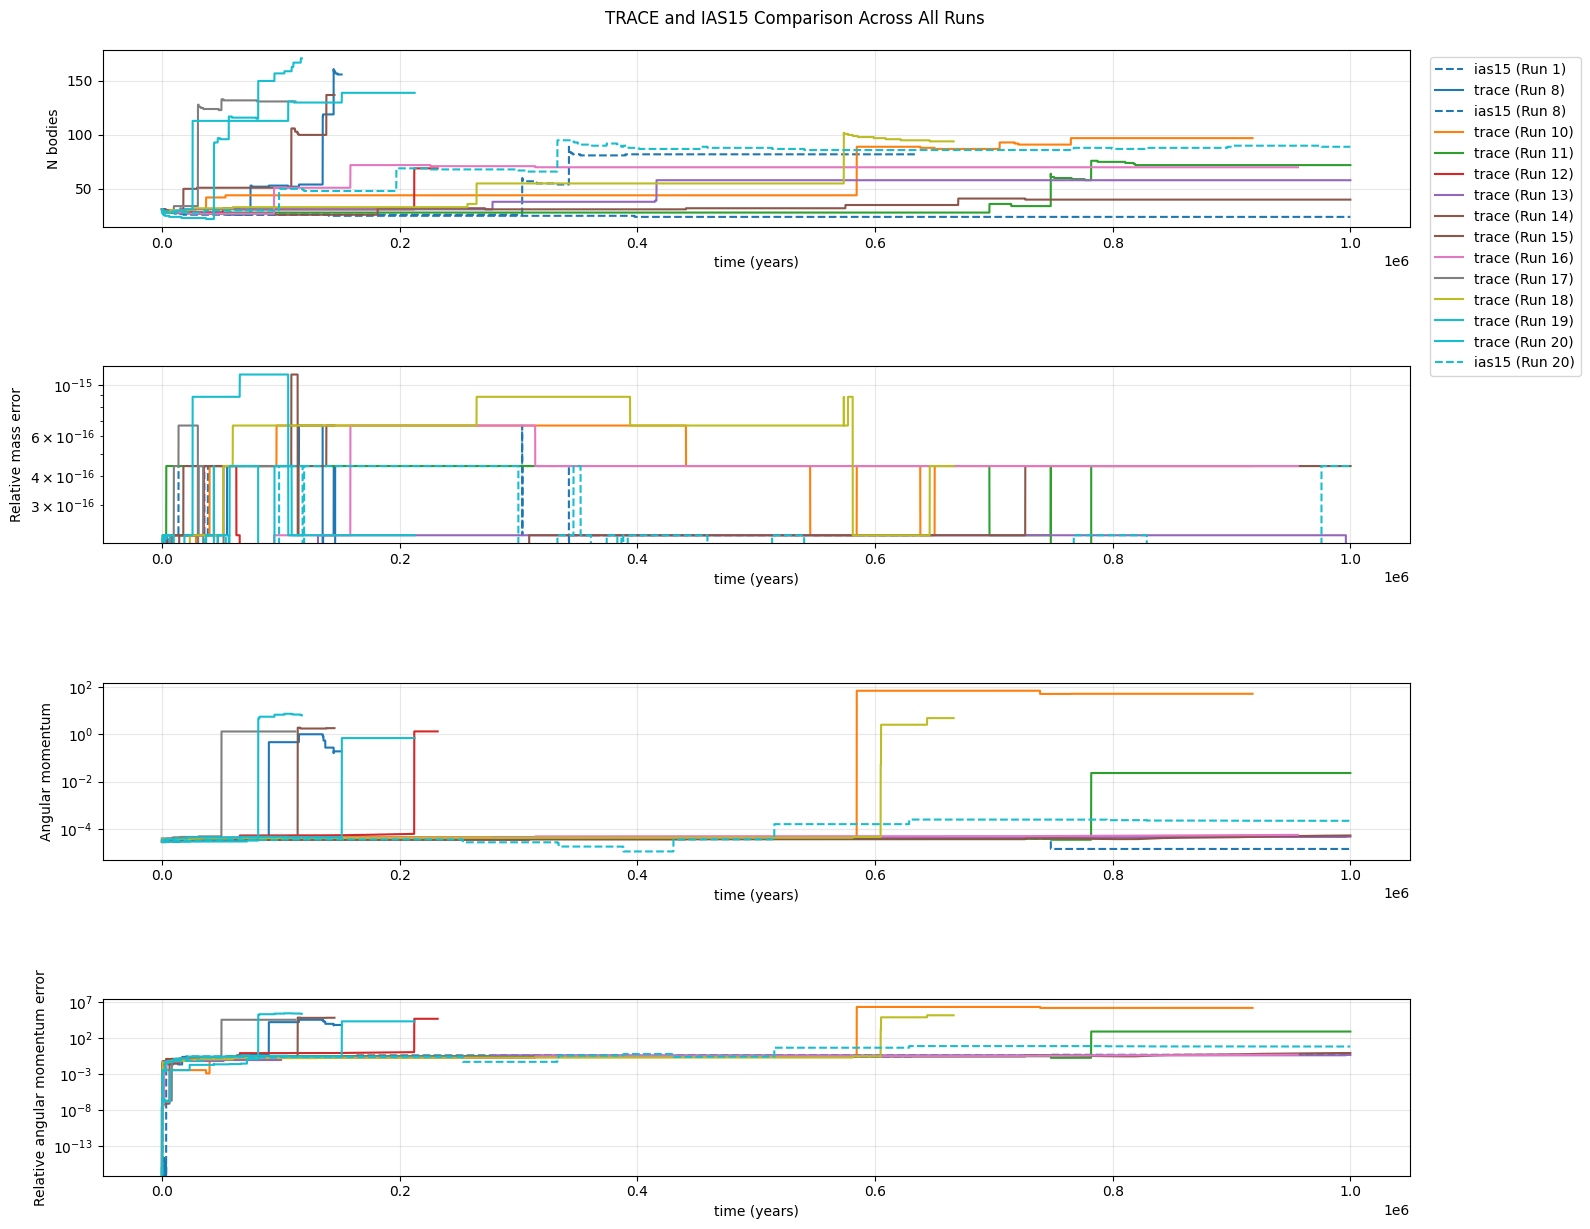

In [157]:
import matplotlib.pyplot as plt
import numpy as np

plt.figure(figsize=(16, 12))

# 1. Get unique runs from BOTH dataframes and combine them
runs_ias15 = set(combined_ias15_df['run_number'].unique())
runs_trace = set(combined_trace_df['run_number'].unique())
all_unique_runs = sorted(list(runs_ias15.union(runs_trace)))

# Generate colors based on the total number of unique runs
colors = plt.cm.tab10(np.linspace(0, 1, len(all_unique_runs)))

for idx, run in enumerate(all_unique_runs):
    color = colors[idx]
    
    # 2. Check and plot Trace data if this run exists in the Trace dataframe
    if run in runs_trace:
        df_tr = combined_trace_df[combined_trace_df['run_number'] == run]
        
        plt.subplot(4, 1, 1)
        plt.plot(df_tr['t'], df_tr['N_Bodies'], color=color, linestyle='-', label=f'trace (Run {run})')
        
        plt.subplot(4, 1, 2)
        plt.plot(df_tr['t'], df_tr['m_errors'], color=color, linestyle='-')
        
        plt.subplot(4, 1, 3)
        plt.plot(df_tr['t'], df_tr['angular_momentums'], color=color, linestyle='-')
        
        plt.subplot(4, 1, 4)
        plt.plot(df_tr['t'], df_tr['L_rel_errors'], color=color, linestyle='-')

    # 3. Check and plot IAS15 data if this run exists in the IAS15 dataframe
    if run in runs_ias15:
        df_ias = combined_ias15_df[combined_ias15_df['run_number'] == run]
        
        plt.subplot(4, 1, 1)
        plt.plot(df_ias['t'], df_ias['N_Bodies'], color=color, linestyle='--', label=f'ias15 (Run {run})')
        
        plt.subplot(4, 1, 2)
        plt.plot(df_ias['t'], df_ias['m_errors'], color=color, linestyle='--')
        
        plt.subplot(4, 1, 3)
        plt.plot(df_ias['t'], df_ias['angular_momentums'], color=color, linestyle='--')
        
        plt.subplot(4, 1, 4)
        plt.plot(df_ias['t'], df_ias['L_rel_errors'], color=color, linestyle='--')


# Format Subplot 1
plt.subplot(4, 1, 1)
plt.legend(bbox_to_anchor=(1.01, 1), loc='upper left')
plt.grid(True, alpha=0.3)
plt.xlabel("time (years)")
plt.ylabel("N bodies")

# Format Subplot 2
plt.subplot(4, 1, 2)
plt.grid(True, alpha=0.3)
plt.xlabel("time (years)")
plt.ylabel("Relative mass error")
plt.yscale("log")

# Format Subplot 3
plt.subplot(4, 1, 3)
plt.yscale("log")
plt.grid(True, alpha=0.3)
plt.xlabel("time (years)")
plt.ylabel("Angular momentum")

# Format Subplot 4
plt.subplot(4, 1, 4)
plt.yscale("log")
plt.grid(True, alpha=0.3)
plt.xlabel("time (years)")
plt.ylabel("Relative angular momentum error")

plt.tight_layout()
plt.suptitle("TRACE and IAS15 Comparison Across All Runs", y=1.02)
plt.show()

In [179]:
base_dir_trace = "/Users/honeyeah/Codes/data/embryo_trace_output_downloads"
search_pattern = os.path.join(base_dir_trace, "famtree_*")

# List to store each individual DataFrame before combining them
all_trace_famtree_dfs = []

for file_path in glob.glob(search_pattern):
    # Extract the run number from the filename
    filename = os.path.basename(file_path)
    run_number = int(filename.split('_')[-1])
    
    df = pd.read_csv(file_path,
                     header=None, 
                     names=["t", "type", "new_id", "parent1_id", "parent2_id",
                            "new_mass", "parent1_mass", "parent2_mass", "new_radius",
                            "parent1_radius", "parent2_radius", "v_imp", "theta_imp"])

    df['run_number'] = run_number
    
    all_trace_famtree_dfs.append(df)

# Combine all the individual DataFrames into one large DataFrame
trace_famtrees = pd.concat(all_trace_famtree_dfs, ignore_index=True)

# View the result
trace_famtrees.head()

,t,type,new_id,parent1_id,parent2_id,new_mass,parent1_mass,parent2_mass,new_radius,parent1_radius,parent2_radius,v_imp,theta_imp,run_number
0,42.04955,2,31,27,9,8.501161e-07,3.672676e-07,4.828485e-07,0.000034,0.000026,0.000028,1.298984,0.970559,17
1,952.30940,2,33,29,30,8.451997e-07,3.603844e-07,4.848153e-07,0.000034,0.000026,0.000028,1.134121,1.096677,17
2,3368.79800,10,35,7,21,4.336776e-07,4.336776e-07,2.385443e-07,0.000027,0.000027,0.000022,1.398629,1.076217,17
3,3368.79800,10,36,7,21,2.385443e-07,4.336776e-07,2.385443e-07,0.000022,0.000027,0.000022,1.398629,1.076217,17
4,8254.65100,4,38,17,14,8.905379e-07,5.331059e-07,5.064926e-07,0.000035,0.000029,0.000029,1.887347,0.526215,17


In [180]:
trace_famtrees['v_esc'] = get_v_esc(
    m1 = trace_famtrees['parent1_mass'],
    m2 = trace_famtrees['parent2_mass'],
    r1 = trace_famtrees['parent1_radius'],
    r2 = trace_famtrees['parent2_radius']
)

# 2. Calculate the ratio of impact velocity to escape velocity
trace_famtrees['v_imp/v_esc'] = trace_famtrees['v_imp'] / trace_famtrees['v_esc']

# Check the results to make sure the new columns look correct
trace_famtrees.head()

,t,type,new_id,parent1_id,parent2_id,new_mass,parent1_mass,parent2_mass,new_radius,parent1_radius,parent2_radius,v_imp,theta_imp,run_number,v_esc,v_imp/v_esc
0,42.04955,2,31,27,9,8.501161e-07,3.672676e-07,4.828485e-07,0.000034,0.000026,0.000028,1.298984,0.970559,17,1.112198,1.167943
1,952.30940,2,33,29,30,8.451997e-07,3.603844e-07,4.848153e-07,0.000034,0.000026,0.000028,1.134121,1.096677,17,1.110250,1.021500
2,3368.79800,10,35,7,21,4.336776e-07,4.336776e-07,2.385443e-07,0.000027,0.000027,0.000022,1.398629,1.076217,17,1.032415,1.354716
3,3368.79800,10,36,7,21,2.385443e-07,4.336776e-07,2.385443e-07,0.000022,0.000027,0.000022,1.398629,1.076217,17,1.032415,1.354716
4,8254.65100,4,38,17,14,8.905379e-07,5.331059e-07,5.064926e-07,0.000035,0.000029,0.000029,1.887347,0.526215,17,1.188168,1.588452


In [215]:
# Group by the specific collision event and count the number of rows (fragments)
trace_famtrees['n_frag'] = trace_famtrees.groupby(
    ['run_number', 'parent1_id', 'parent2_id']
)['new_id'].transform('count')

# View the result to verify
trace_famtrees.head()

,t,type,new_id,parent1_id,parent2_id,new_mass,parent1_mass,parent2_mass,new_radius,parent1_radius,parent2_radius,v_imp,theta_imp,run_number,v_esc,v_imp/v_esc,n_frag
0,42.04955,2,31,27,9,8.501161e-07,3.672676e-07,4.828485e-07,0.000034,0.000026,0.000028,1.298984,0.970559,17,1.112198,1.167943,1
1,952.30940,2,33,29,30,8.451997e-07,3.603844e-07,4.848153e-07,0.000034,0.000026,0.000028,1.134121,1.096677,17,1.110250,1.021500,1
2,3368.79800,10,35,7,21,4.336776e-07,4.336776e-07,2.385443e-07,0.000027,0.000027,0.000022,1.398629,1.076217,17,1.032415,1.354716,2
3,3368.79800,10,36,7,21,2.385443e-07,4.336776e-07,2.385443e-07,0.000022,0.000027,0.000022,1.398629,1.076217,17,1.032415,1.354716,2
4,8254.65100,4,38,17,14,8.905379e-07,5.331059e-07,5.064926e-07,0.000035,0.000029,0.000029,1.887347,0.526215,17,1.188168,1.588452,2


In [181]:
trace_unique_colls = trace_famtrees.drop_duplicates(
    subset=['run_number', 'parent1_id', 'parent2_id'], 
    keep='first'
)

In [182]:
base_dir_ias15 = "/Users/honeyeah/Codes/data/embryo_ias15_output_downloads"
search_pattern = os.path.join(base_dir_ias15, "famtree_*")

# List to store each individual DataFrame before combining them
all_ias15_famtree_dfs = []

for file_path in glob.glob(search_pattern):
    # Extract the run number from the filename
    filename = os.path.basename(file_path)
    run_number = int(filename.split('_')[-1])
    
    df = pd.read_csv(file_path,
                     header=None, 
                     names=["t", "type", "new_id", "parent1_id", "parent2_id",
                            "new_mass", "parent1_mass", "parent2_mass", "new_radius",
                            "parent1_radius", "parent2_radius", "v_imp", "theta_imp"])

    df['run_number'] = run_number
    
    all_ias15_famtree_dfs.append(df)

# Combine all the individual DataFrames into one large DataFrame
ias15_famtrees = pd.concat(all_ias15_famtree_dfs, ignore_index=True)

# View the result
ias15_famtrees.head()

,t,type,new_id,parent1_id,parent2_id,new_mass,parent1_mass,parent2_mass,new_radius,parent1_radius,parent2_radius,v_imp,theta_imp,run_number
0,269.5570,4,31,6,24,5.456989e-07,3.909190e-07,1.982660e-07,0.000030,0.000026,0.000021,1.022707,0.381793,20
1,269.5570,4,32,6,24,4.348606e-08,3.909190e-07,1.982660e-07,0.000013,0.000026,0.000021,1.022707,0.381793,20
2,355.0850,2,34,29,16,4.927830e-07,4.692984e-07,2.348454e-08,0.000029,0.000028,0.000010,1.044921,0.912382,20
3,623.6515,10,36,4,28,4.538866e-07,4.538866e-07,4.192505e-07,0.000028,0.000028,0.000027,1.313900,0.872469,20
4,623.6515,10,37,4,28,4.192505e-07,4.538866e-07,4.192505e-07,0.000027,0.000028,0.000027,1.313900,0.872469,20


In [183]:
ias15_famtrees['v_esc'] = get_v_esc(
    m1 = ias15_famtrees['parent1_mass'],
    m2 = ias15_famtrees['parent2_mass'],
    r1 = ias15_famtrees['parent1_radius'],
    r2 = ias15_famtrees['parent2_radius']
)

# 2. Calculate the ratio of impact velocity to escape velocity
ias15_famtrees['v_imp/v_esc'] = ias15_famtrees['v_imp'] / ias15_famtrees['v_esc']

# Check the results to make sure the new columns look correct
ias15_famtrees.head()

,t,type,new_id,parent1_id,parent2_id,new_mass,parent1_mass,parent2_mass,new_radius,parent1_radius,parent2_radius,v_imp,theta_imp,run_number,v_esc,v_imp/v_esc
0,269.5570,4,31,6,24,5.456989e-07,3.909190e-07,1.982660e-07,0.000030,0.000026,0.000021,1.022707,0.381793,20,0.989379,1.033686
1,269.5570,4,32,6,24,4.348606e-08,3.909190e-07,1.982660e-07,0.000013,0.000026,0.000021,1.022707,0.381793,20,0.989379,1.033686
2,355.0850,2,34,29,16,4.927830e-07,4.692984e-07,2.348454e-08,0.000029,0.000028,0.000010,1.044921,0.912382,20,1.005880,1.038813
3,623.6515,10,36,4,28,4.538866e-07,4.538866e-07,4.192505e-07,0.000028,0.000028,0.000027,1.313900,0.872469,20,1.121086,1.171989
4,623.6515,10,37,4,28,4.192505e-07,4.538866e-07,4.192505e-07,0.000027,0.000028,0.000027,1.313900,0.872469,20,1.121086,1.171989


In [216]:
# Group by the specific collision event and count the number of rows (fragments)
ias15_famtrees['n_frag'] = ias15_famtrees.groupby(
    ['run_number', 'parent1_id', 'parent2_id']
)['new_id'].transform('count')

# View the result to verify
ias15_famtrees.head()

,t,type,new_id,parent1_id,parent2_id,new_mass,parent1_mass,parent2_mass,new_radius,parent1_radius,parent2_radius,v_imp,theta_imp,run_number,v_esc,v_imp/v_esc,n_frag
0,269.5570,4,31,6,24,5.456989e-07,3.909190e-07,1.982660e-07,0.000030,0.000026,0.000021,1.022707,0.381793,20,0.989379,1.033686,2
1,269.5570,4,32,6,24,4.348606e-08,3.909190e-07,1.982660e-07,0.000013,0.000026,0.000021,1.022707,0.381793,20,0.989379,1.033686,2
2,355.0850,2,34,29,16,4.927830e-07,4.692984e-07,2.348454e-08,0.000029,0.000028,0.000010,1.044921,0.912382,20,1.005880,1.038813,1
3,623.6515,10,36,4,28,4.538866e-07,4.538866e-07,4.192505e-07,0.000028,0.000028,0.000027,1.313900,0.872469,20,1.121086,1.171989,2
4,623.6515,10,37,4,28,4.192505e-07,4.538866e-07,4.192505e-07,0.000027,0.000028,0.000027,1.313900,0.872469,20,1.121086,1.171989,2


In [184]:
ias15_unique_colls = ias15_famtrees.drop_duplicates(
    subset=['run_number', 'parent1_id', 'parent2_id'], 
    keep='first'
)

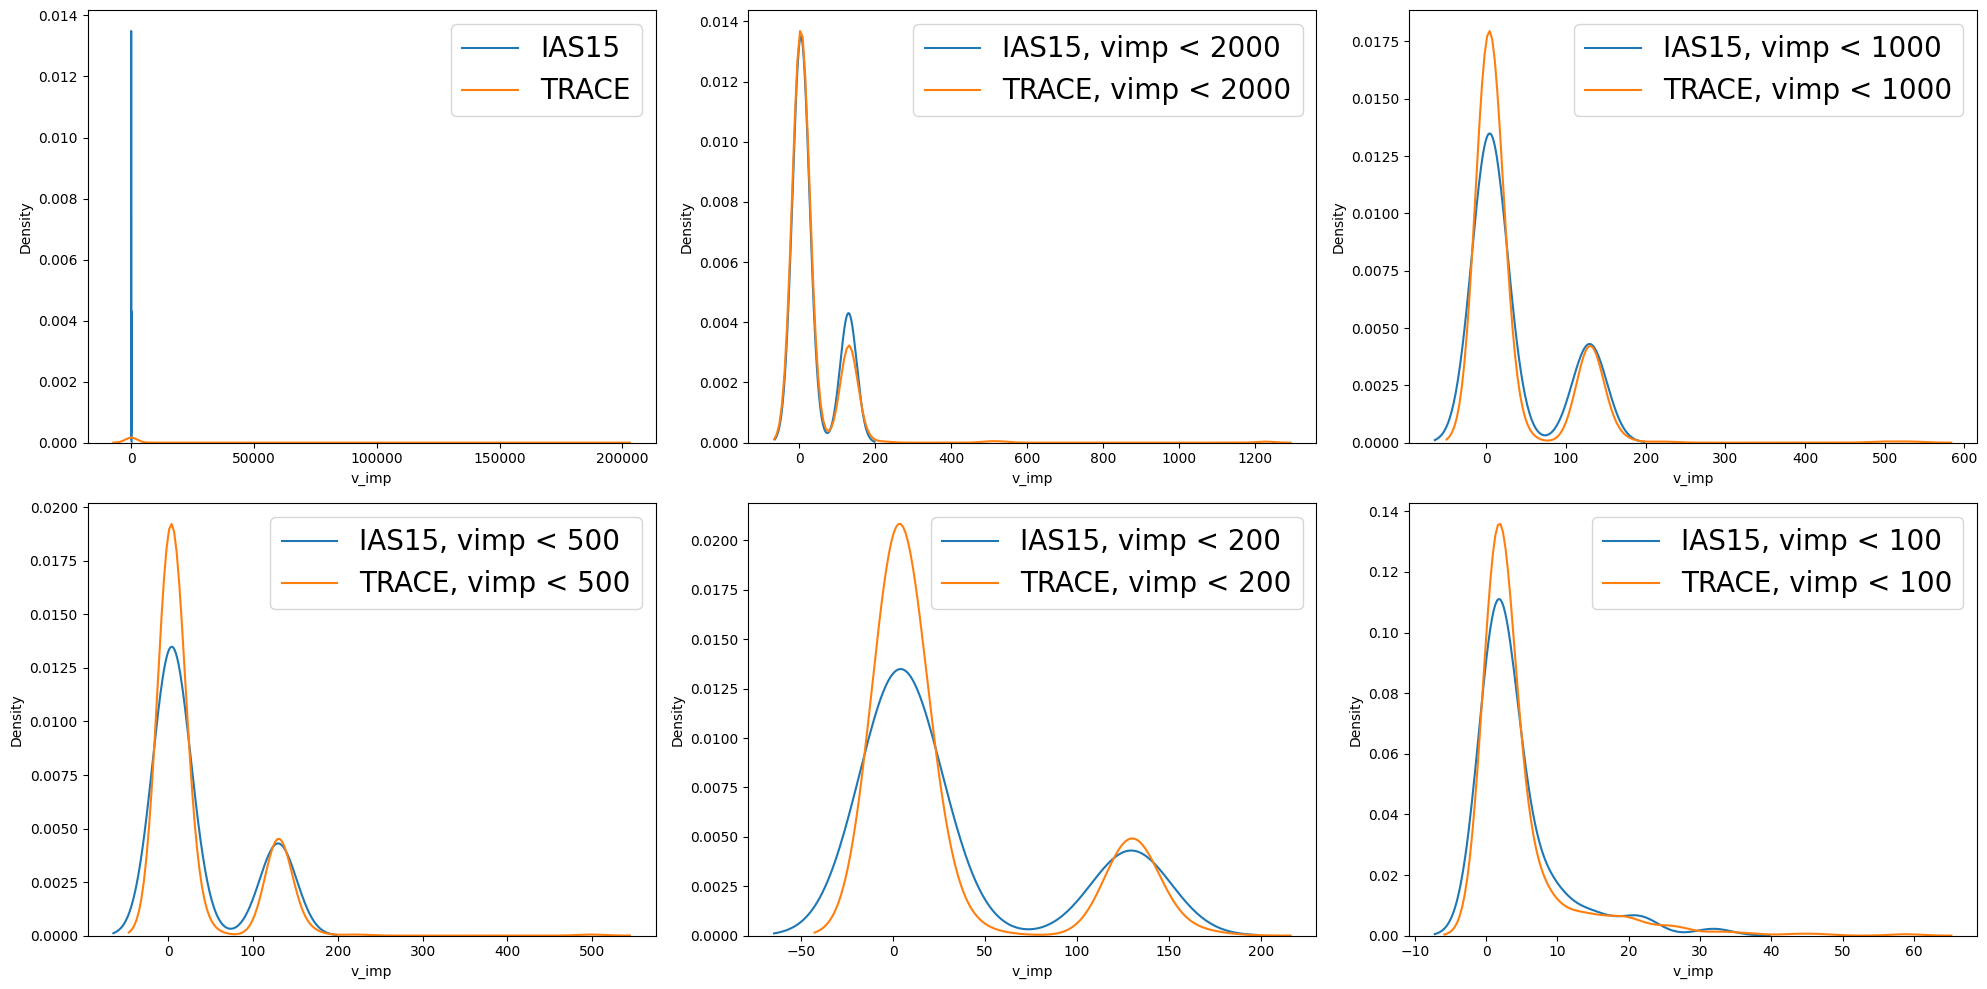

In [185]:
plt.figure(figsize=(20,10))

plt.subplot(2,3,1)
sns.kdeplot(ias15_unique_colls['v_imp'], label='IAS15')
sns.kdeplot(trace_unique_colls['v_imp'], label='TRACE')

plt.xlabel('v_imp')
plt.ylabel('Density')
plt.legend(fontsize=20)

plt.subplot(2,3,2)
vimp_thresh = 2000
trace_unique_colls_filtered = trace_unique_colls[trace_unique_colls['v_imp'] < vimp_thresh]
ias15_unique_colls_filtered = ias15_unique_colls[ias15_unique_colls['v_imp'] < vimp_thresh]
sns.kdeplot(ias15_unique_colls_filtered['v_imp'], label=f'IAS15, vimp < {vimp_thresh}')
sns.kdeplot(trace_unique_colls_filtered['v_imp'], label=f'TRACE, vimp < {vimp_thresh}')
plt.xlabel('v_imp')
plt.ylabel('Density')
plt.legend(fontsize=20)


plt.subplot(2,3,3)
vimp_thresh = 1000
trace_unique_colls_filtered = trace_unique_colls[trace_unique_colls['v_imp'] < vimp_thresh]
ias15_unique_colls_filtered = ias15_unique_colls[ias15_unique_colls['v_imp'] < vimp_thresh]
sns.kdeplot(ias15_unique_colls_filtered['v_imp'], label=f'IAS15, vimp < {vimp_thresh}')
sns.kdeplot(trace_unique_colls_filtered['v_imp'], label=f'TRACE, vimp < {vimp_thresh}')
plt.xlabel('v_imp')
plt.ylabel('Density')
plt.legend(fontsize=20)


plt.subplot(2,3,4)
vimp_thresh = 500
trace_unique_colls_filtered = trace_unique_colls[trace_unique_colls['v_imp'] < vimp_thresh]
ias15_unique_colls_filtered = ias15_unique_colls[ias15_unique_colls['v_imp'] < vimp_thresh]
sns.kdeplot(ias15_unique_colls_filtered['v_imp'], label=f'IAS15, vimp < {vimp_thresh}')
sns.kdeplot(trace_unique_colls_filtered['v_imp'], label=f'TRACE, vimp < {vimp_thresh}')
plt.xlabel('v_imp')
plt.ylabel('Density')
plt.legend(fontsize=20)


plt.subplot(2,3,5)
vimp_thresh = 200
trace_unique_colls_filtered = trace_unique_colls[trace_unique_colls['v_imp'] < vimp_thresh]
ias15_unique_colls_filtered = ias15_unique_colls[ias15_unique_colls['v_imp'] < vimp_thresh]
sns.kdeplot(ias15_unique_colls_filtered['v_imp'], label=f'IAS15, vimp < {vimp_thresh}')
sns.kdeplot(trace_unique_colls_filtered['v_imp'], label=f'TRACE, vimp < {vimp_thresh}')
plt.xlabel('v_imp')
plt.ylabel('Density')
plt.legend(fontsize=20)

plt.subplot(2,3,6)
vimp_thresh = 100
trace_unique_colls_filtered = trace_unique_colls[trace_unique_colls['v_imp'] < vimp_thresh]
ias15_unique_colls_filtered = ias15_unique_colls[ias15_unique_colls['v_imp'] < vimp_thresh]
sns.kdeplot(ias15_unique_colls_filtered['v_imp'], label=f'IAS15, vimp < {vimp_thresh}')
sns.kdeplot(trace_unique_colls_filtered['v_imp'], label=f'TRACE, vimp < {vimp_thresh}')
plt.xlabel('v_imp')
plt.ylabel('Density')
plt.legend(fontsize=20)

plt.tight_layout()

/var/folders/g0/fl404sj151l2v9xcdkjz9fq80000gn/T/ipykernel_14307/3839580815.py:65: UserWarning: Dataset has 0 variance; skipping density estimate. Pass `warn_singular=False` to disable this warning.
  sns.kdeplot(trace_unique_colls_filtered['v_imp'], label=f'TRACE, vimp > {vimp_thresh}')
/var/folders/g0/fl404sj151l2v9xcdkjz9fq80000gn/T/ipykernel_14307/3839580815.py:69: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend(fontsize=20)


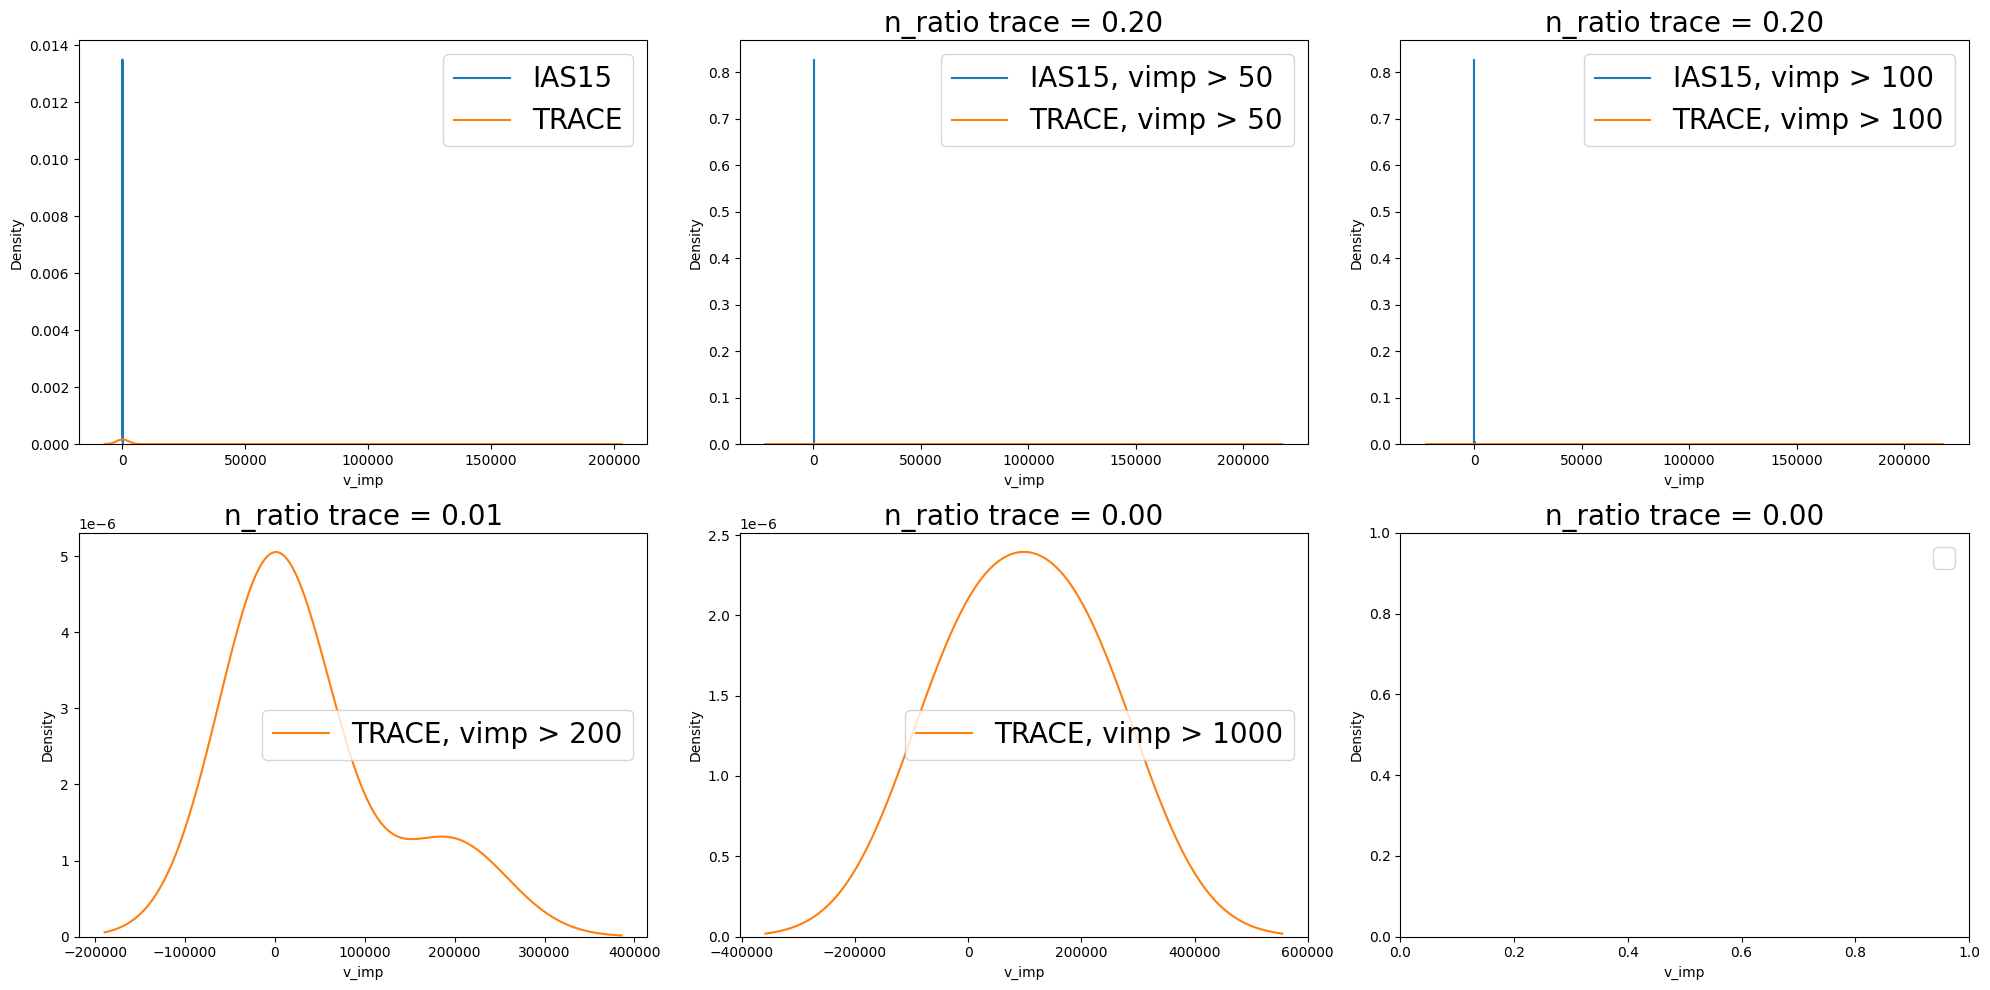

In [186]:
plt.figure(figsize=(20,10))

n_tot_coll_trace = len(trace_unique_colls)

plt.subplot(2,3,1)
sns.kdeplot(ias15_unique_colls['v_imp'], label='IAS15')
sns.kdeplot(trace_unique_colls['v_imp'], label='TRACE')

plt.xlabel('v_imp')
plt.ylabel('Density')
plt.legend(fontsize=20)

plt.subplot(2,3,2)
vimp_thresh = 50
trace_unique_colls_filtered = trace_unique_colls[trace_unique_colls['v_imp'] > vimp_thresh]
ias15_unique_colls_filtered = ias15_unique_colls[ias15_unique_colls['v_imp'] > vimp_thresh]
sns.kdeplot(ias15_unique_colls_filtered['v_imp'], label=f'IAS15, vimp > {vimp_thresh}')
sns.kdeplot(trace_unique_colls_filtered['v_imp'], label=f'TRACE, vimp > {vimp_thresh}')
plt.title(f"n_ratio trace = {(len(trace_unique_colls_filtered)/n_tot_coll_trace):.2f}", fontsize=20)
plt.xlabel('v_imp')
plt.ylabel('Density')
plt.legend(fontsize=20)


plt.subplot(2,3,3)
vimp_thresh = 100
trace_unique_colls_filtered = trace_unique_colls[trace_unique_colls['v_imp'] > vimp_thresh]
ias15_unique_colls_filtered = ias15_unique_colls[ias15_unique_colls['v_imp'] > vimp_thresh]
sns.kdeplot(ias15_unique_colls_filtered['v_imp'], label=f'IAS15, vimp > {vimp_thresh}')
sns.kdeplot(trace_unique_colls_filtered['v_imp'], label=f'TRACE, vimp > {vimp_thresh}')
plt.title(f"n_ratio trace = {(len(trace_unique_colls_filtered)/n_tot_coll_trace):.2f}", fontsize=20)
plt.xlabel('v_imp')
plt.ylabel('Density')
plt.legend(fontsize=20)


plt.subplot(2,3,4)
vimp_thresh = 200
trace_unique_colls_filtered = trace_unique_colls[trace_unique_colls['v_imp'] > vimp_thresh]
ias15_unique_colls_filtered = ias15_unique_colls[ias15_unique_colls['v_imp'] > vimp_thresh]
sns.kdeplot(ias15_unique_colls_filtered['v_imp'], label=f'IAS15, vimp > {vimp_thresh}')
sns.kdeplot(trace_unique_colls_filtered['v_imp'], label=f'TRACE, vimp > {vimp_thresh}')
plt.title(f"n_ratio trace = {(len(trace_unique_colls_filtered)/n_tot_coll_trace):.2f}", fontsize=20)
plt.xlabel('v_imp')
plt.ylabel('Density')
plt.legend(fontsize=20)


plt.subplot(2,3,5)
vimp_thresh = 1000
trace_unique_colls_filtered = trace_unique_colls[trace_unique_colls['v_imp'] > vimp_thresh]
ias15_unique_colls_filtered = ias15_unique_colls[ias15_unique_colls['v_imp'] > vimp_thresh]
sns.kdeplot(ias15_unique_colls_filtered['v_imp'], label=f'IAS15, vimp > {vimp_thresh}')
sns.kdeplot(trace_unique_colls_filtered['v_imp'], label=f'TRACE, vimp > {vimp_thresh}')
plt.title(f"n_ratio trace = {(len(trace_unique_colls_filtered)/n_tot_coll_trace):.2f}", fontsize=20)
plt.xlabel('v_imp')
plt.ylabel('Density')
plt.legend(fontsize=20)

plt.subplot(2,3,6)
vimp_thresh = 2000
trace_unique_colls_filtered = trace_unique_colls[trace_unique_colls['v_imp'] > vimp_thresh]
ias15_unique_colls_filtered = ias15_unique_colls[ias15_unique_colls['v_imp'] > vimp_thresh]
sns.kdeplot(ias15_unique_colls_filtered['v_imp'], label=f'IAS15, vimp > {vimp_thresh}')
sns.kdeplot(trace_unique_colls_filtered['v_imp'], label=f'TRACE, vimp > {vimp_thresh}')
plt.title(f"n_ratio trace = {(len(trace_unique_colls_filtered)/n_tot_coll_trace):.2f}", fontsize=20)
plt.xlabel('v_imp')
plt.ylabel('Density')
plt.legend(fontsize=20)

plt.tight_layout()

/var/folders/g0/fl404sj151l2v9xcdkjz9fq80000gn/T/ipykernel_14307/3987734089.py:65: UserWarning: Dataset has 0 variance; skipping density estimate. Pass `warn_singular=False` to disable this warning.
  sns.kdeplot(trace_unique_colls_filtered['v_imp'], label=f'TRACE, vimp > {vimp_thresh}')
/var/folders/g0/fl404sj151l2v9xcdkjz9fq80000gn/T/ipykernel_14307/3987734089.py:69: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend(fontsize=20)


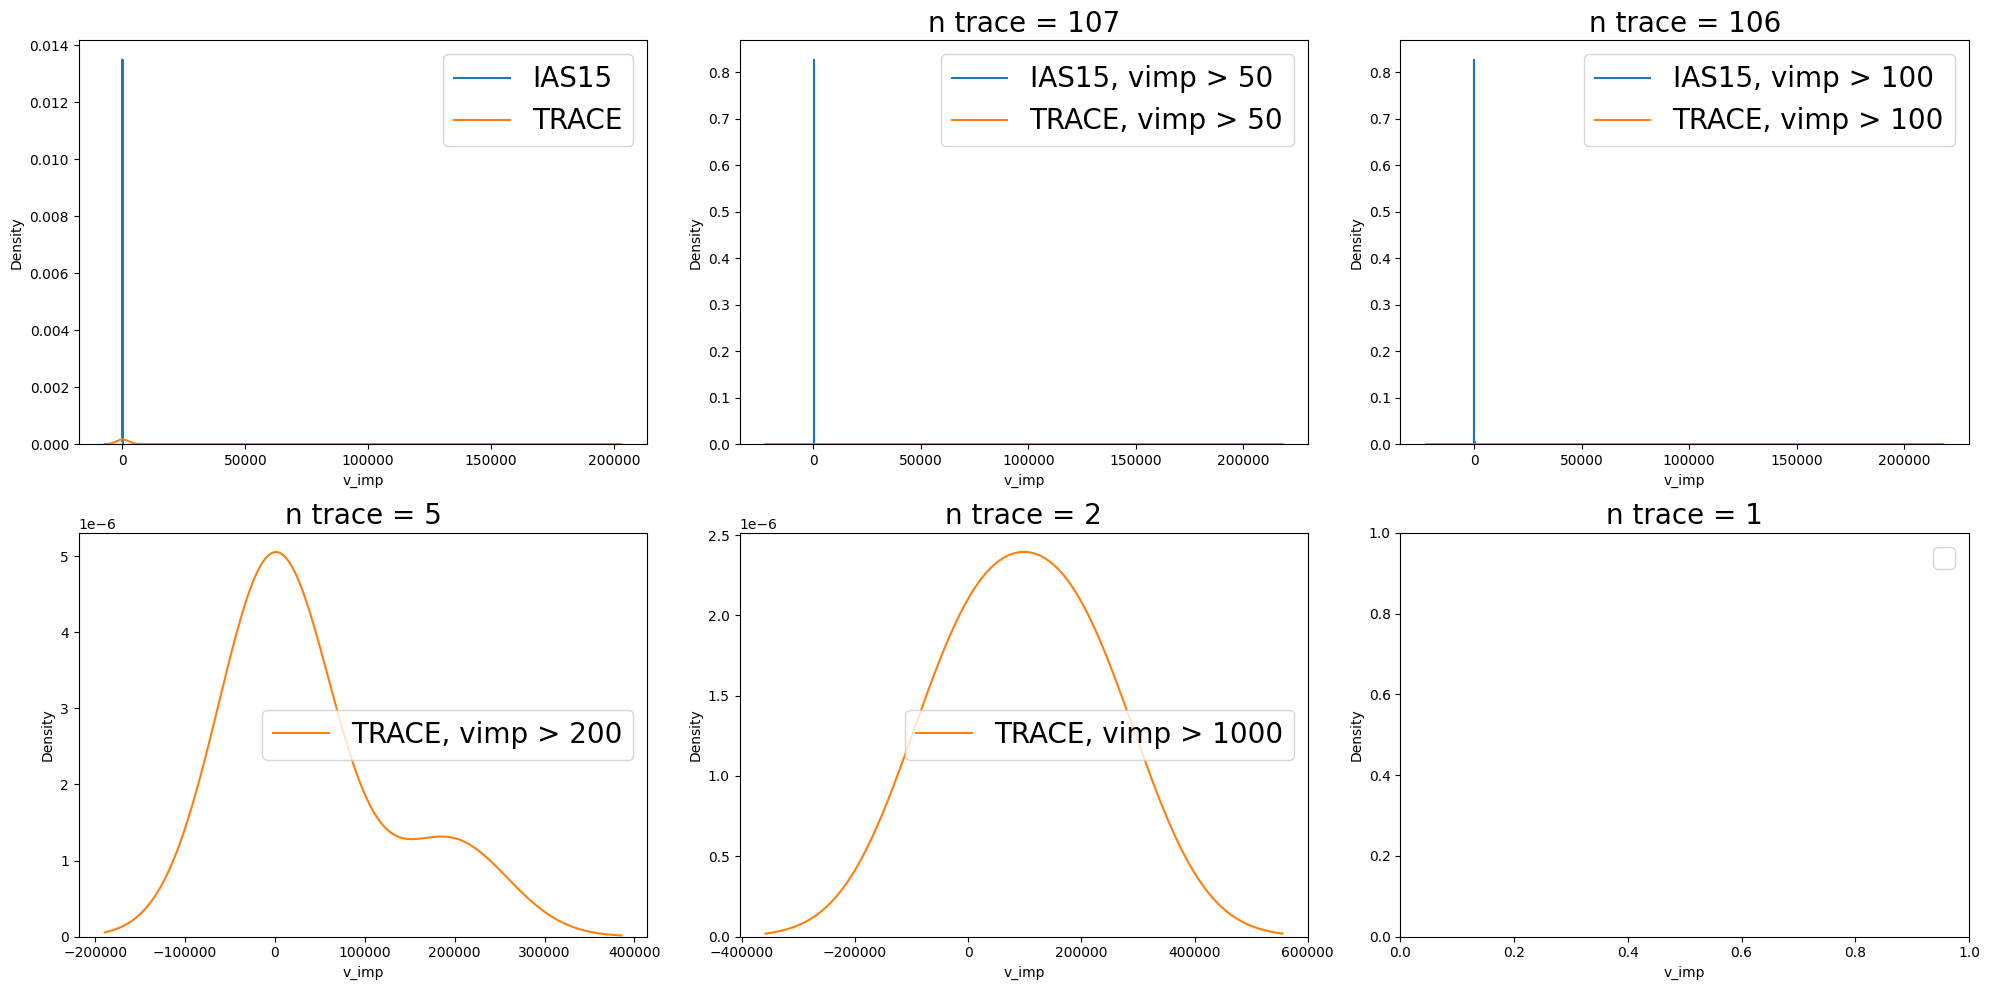

In [187]:
plt.figure(figsize=(20,10))

n_tot_coll_trace = len(trace_unique_colls)

plt.subplot(2,3,1)
sns.kdeplot(ias15_unique_colls['v_imp'], label='IAS15')
sns.kdeplot(trace_unique_colls['v_imp'], label='TRACE')

plt.xlabel('v_imp')
plt.ylabel('Density')
plt.legend(fontsize=20)

plt.subplot(2,3,2)
vimp_thresh = 50
trace_unique_colls_filtered = trace_unique_colls[trace_unique_colls['v_imp'] > vimp_thresh]
ias15_unique_colls_filtered = ias15_unique_colls[ias15_unique_colls['v_imp'] > vimp_thresh]
sns.kdeplot(ias15_unique_colls_filtered['v_imp'], label=f'IAS15, vimp > {vimp_thresh}')
sns.kdeplot(trace_unique_colls_filtered['v_imp'], label=f'TRACE, vimp > {vimp_thresh}')
plt.title(f"n trace = {(len(trace_unique_colls_filtered))}", fontsize=20)
plt.xlabel('v_imp')
plt.ylabel('Density')
plt.legend(fontsize=20)


plt.subplot(2,3,3)
vimp_thresh = 100
trace_unique_colls_filtered = trace_unique_colls[trace_unique_colls['v_imp'] > vimp_thresh]
ias15_unique_colls_filtered = ias15_unique_colls[ias15_unique_colls['v_imp'] > vimp_thresh]
sns.kdeplot(ias15_unique_colls_filtered['v_imp'], label=f'IAS15, vimp > {vimp_thresh}')
sns.kdeplot(trace_unique_colls_filtered['v_imp'], label=f'TRACE, vimp > {vimp_thresh}')
plt.title(f"n trace = {(len(trace_unique_colls_filtered))}", fontsize=20)
plt.xlabel('v_imp')
plt.ylabel('Density')
plt.legend(fontsize=20)


plt.subplot(2,3,4)
vimp_thresh = 200
trace_unique_colls_filtered = trace_unique_colls[trace_unique_colls['v_imp'] > vimp_thresh]
ias15_unique_colls_filtered = ias15_unique_colls[ias15_unique_colls['v_imp'] > vimp_thresh]
sns.kdeplot(ias15_unique_colls_filtered['v_imp'], label=f'IAS15, vimp > {vimp_thresh}')
sns.kdeplot(trace_unique_colls_filtered['v_imp'], label=f'TRACE, vimp > {vimp_thresh}')
plt.title(f"n trace = {(len(trace_unique_colls_filtered))}", fontsize=20)
plt.xlabel('v_imp')
plt.ylabel('Density')
plt.legend(fontsize=20)


plt.subplot(2,3,5)
vimp_thresh = 1000
trace_unique_colls_filtered = trace_unique_colls[trace_unique_colls['v_imp'] > vimp_thresh]
ias15_unique_colls_filtered = ias15_unique_colls[ias15_unique_colls['v_imp'] > vimp_thresh]
sns.kdeplot(ias15_unique_colls_filtered['v_imp'], label=f'IAS15, vimp > {vimp_thresh}')
sns.kdeplot(trace_unique_colls_filtered['v_imp'], label=f'TRACE, vimp > {vimp_thresh}')
plt.title(f"n trace = {(len(trace_unique_colls_filtered))}", fontsize=20)
plt.xlabel('v_imp')
plt.ylabel('Density')
plt.legend(fontsize=20)

plt.subplot(2,3,6)
vimp_thresh = 2000
trace_unique_colls_filtered = trace_unique_colls[trace_unique_colls['v_imp'] > vimp_thresh]
ias15_unique_colls_filtered = ias15_unique_colls[ias15_unique_colls['v_imp'] > vimp_thresh]
sns.kdeplot(ias15_unique_colls_filtered['v_imp'], label=f'IAS15, vimp > {vimp_thresh}')
sns.kdeplot(trace_unique_colls_filtered['v_imp'], label=f'TRACE, vimp > {vimp_thresh}')
plt.title(f"n trace = {(len(trace_unique_colls_filtered))}", fontsize=20)
plt.xlabel('v_imp')
plt.ylabel('Density')
plt.legend(fontsize=20)

plt.tight_layout()

In [188]:
max_vimp_trace = np.max(trace_unique_colls['v_imp'])
print("max vimp trace = ", max_vimp_trace)

max_vimp_ias15 = np.max(ias15_unique_colls['v_imp'])
print("max vimp ias15 = ", max_vimp_ias15)

max vimp trace =  195798.2
max vimp ias15 =  132.3335


/var/folders/g0/fl404sj151l2v9xcdkjz9fq80000gn/T/ipykernel_14307/868486702.py:16: UserWarning: Dataset has 0 variance; skipping density estimate. Pass `warn_singular=False` to disable this warning.
  sns.kdeplot(trace_unique_colls_filtered['v_imp'], label='TRACE')
/var/folders/g0/fl404sj151l2v9xcdkjz9fq80000gn/T/ipykernel_14307/868486702.py:20: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend(fontsize=15)
/var/folders/g0/fl404sj151l2v9xcdkjz9fq80000gn/T/ipykernel_14307/868486702.py:16: UserWarning: Dataset has 0 variance; skipping density estimate. Pass `warn_singular=False` to disable this warning.
  sns.kdeplot(trace_unique_colls_filtered['v_imp'], label='TRACE')
/var/folders/g0/fl404sj151l2v9xcdkjz9fq80000gn/T/ipykernel_14307/868486702.py:20: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an under

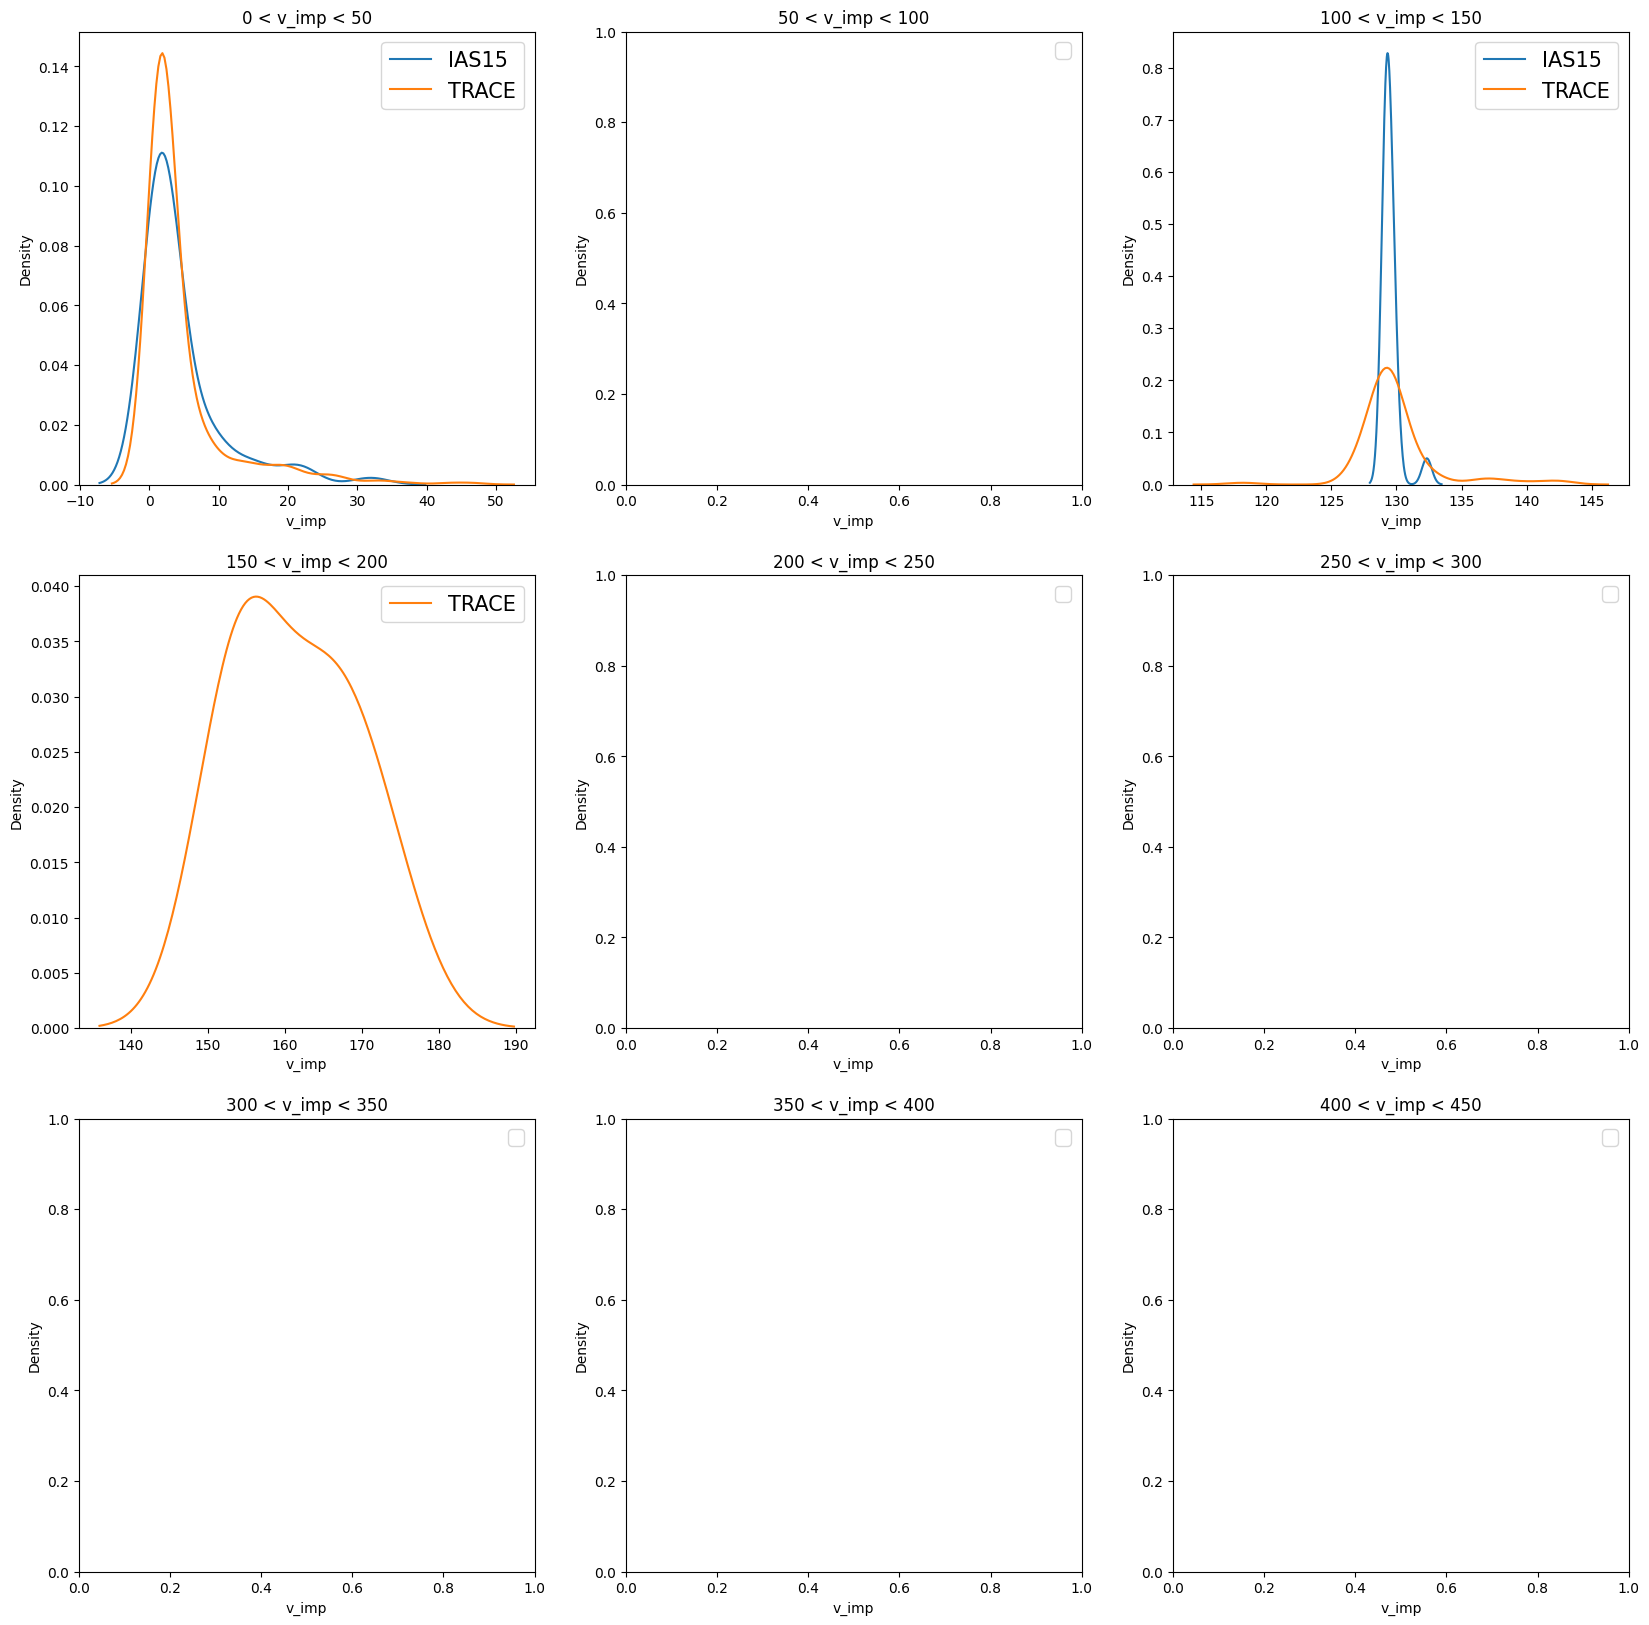

In [189]:
range_start = 0
range_end = 500
bin_len = 50

bins = np.arange(range_start,range_end,bin_len)

plt.figure(figsize=(20,20))

for i in range(len(bins) - 1):
    plt.subplot(3, 3, i+1)
    low_lim = bins[i]
    up_lim = bins[i+1]
    trace_unique_colls_filtered = trace_unique_colls[(trace_unique_colls['v_imp'] < up_lim) & (trace_unique_colls['v_imp'] > low_lim)]
    ias15_unique_colls_filtered = ias15_unique_colls[(ias15_unique_colls['v_imp'] < up_lim) & ((ias15_unique_colls['v_imp'] > low_lim))]
    sns.kdeplot(ias15_unique_colls_filtered['v_imp'], label='IAS15')
    sns.kdeplot(trace_unique_colls_filtered['v_imp'], label='TRACE')
    plt.title(f"{low_lim} < v_imp < {up_lim}")
    plt.xlabel('v_imp')
    plt.ylabel('Density')
    plt.legend(fontsize=15)

/var/folders/g0/fl404sj151l2v9xcdkjz9fq80000gn/T/ipykernel_14307/1244948875.py:15: UserWarning: Dataset has 0 variance; skipping density estimate. Pass `warn_singular=False` to disable this warning.
  sns.kdeplot(ias15_unique_colls_filtered['v_imp'], label='IAS15')
/var/folders/g0/fl404sj151l2v9xcdkjz9fq80000gn/T/ipykernel_14307/1244948875.py:16: UserWarning: Dataset has 0 variance; skipping density estimate. Pass `warn_singular=False` to disable this warning.
  sns.kdeplot(trace_unique_colls_filtered['v_imp'], label='TRACE, vimp < 100')
/var/folders/g0/fl404sj151l2v9xcdkjz9fq80000gn/T/ipykernel_14307/1244948875.py:20: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend(fontsize=15)
/var/folders/g0/fl404sj151l2v9xcdkjz9fq80000gn/T/ipykernel_14307/1244948875.py:20: UserWarning: No artists with labels found to put in legend.  Note that artists whose label sta

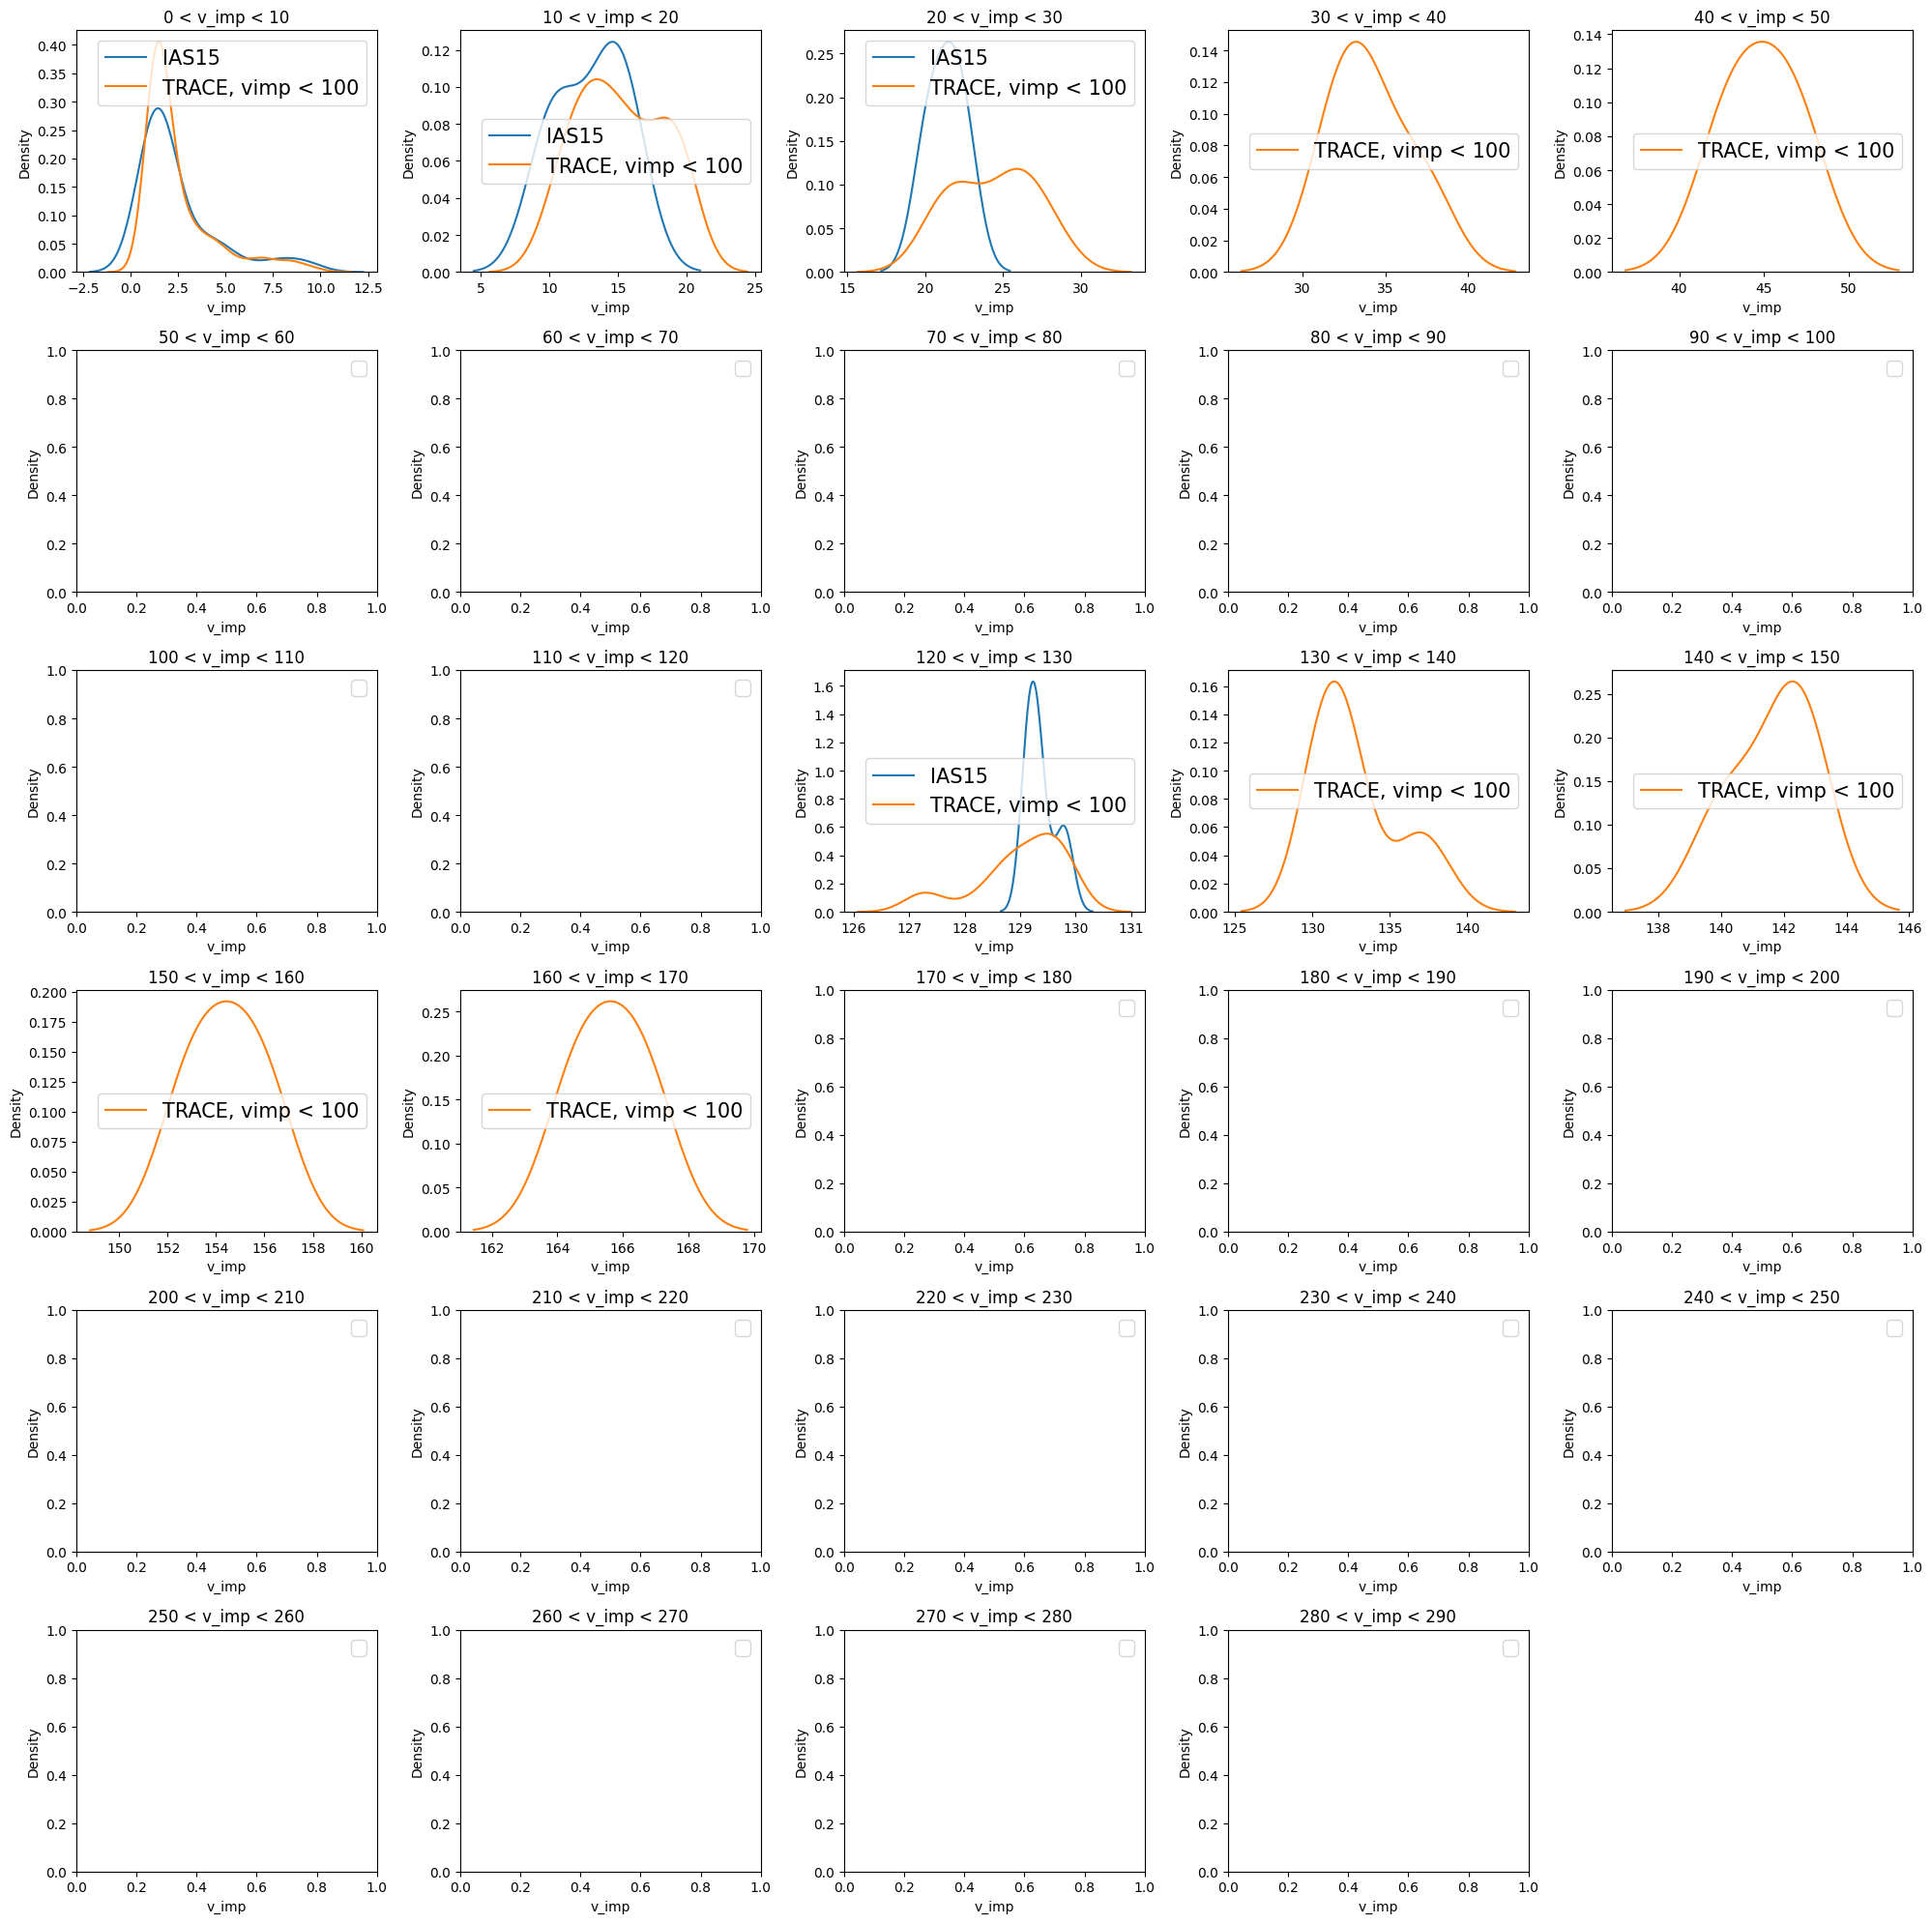

In [190]:
range_start = 0
range_end = 300
bin_len = 10

bins = np.arange(range_start,range_end,bin_len)

plt.figure(figsize=(20,20))

for i in range(len(bins) - 1):
    plt.subplot(6, 5, i+1)
    low_lim = bins[i]
    up_lim = bins[i+1]
    trace_unique_colls_filtered = trace_unique_colls[(trace_unique_colls['v_imp'] < up_lim) & (trace_unique_colls['v_imp'] > low_lim)]
    ias15_unique_colls_filtered = ias15_unique_colls[(ias15_unique_colls['v_imp'] < up_lim) & ((ias15_unique_colls['v_imp'] > low_lim))]
    sns.kdeplot(ias15_unique_colls_filtered['v_imp'], label='IAS15')
    sns.kdeplot(trace_unique_colls_filtered['v_imp'], label='TRACE, vimp < 100')
    plt.title(f"{low_lim} < v_imp < {up_lim}")
    plt.xlabel('v_imp')
    plt.ylabel('Density')
    plt.legend(fontsize=15)

plt.tight_layout()

# Matching collisions with their archive snapshot

In [217]:
combined_trace_df

,t,N_Bodies,total_masses,m_errors,angular_momentums,L_rel_errors,run_number
0,0.000000,31,1.000009,0.0,0.000032,0.000000e+00,13
1,10.010959,31,1.000009,0.0,0.000032,7.205687e-12,13
2,20.005479,31,1.000009,0.0,0.000032,1.430082e-11,13
3,30.016438,31,1.000009,0.0,0.000032,1.925293e-11,13
4,40.010959,31,1.000009,0.0,0.000032,2.289919e-11,13
...,...,...,...,...,...,...,...
651090,151150.010957,156,1.000009,0.0,0.190874,6.459898e+03,8
651091,151160.005477,156,1.000009,0.0,0.190874,6.459898e+03,8
651092,151170.016436,156,1.000009,0.0,0.190874,6.459899e+03,8
651093,151180.010957,156,1.000009,0.0,0.190874,6.459899e+03,8


In [218]:
trace_famtrees

,t,type,new_id,parent1_id,parent2_id,new_mass,parent1_mass,parent2_mass,new_radius,parent1_radius,parent2_radius,v_imp,theta_imp,run_number,v_esc,v_imp/v_esc,n_frag
0,42.04955,2,31,27,9,8.501161e-07,3.672676e-07,4.828485e-07,0.000034,0.000026,0.000028,1.298984,0.970559,17,1.112198,1.167943,1
1,952.30940,2,33,29,30,8.451997e-07,3.603844e-07,4.848153e-07,0.000034,0.000026,0.000028,1.134121,1.096677,17,1.110250,1.021500,1
2,3368.79800,10,35,7,21,4.336776e-07,4.336776e-07,2.385443e-07,0.000027,0.000027,0.000022,1.398629,1.076217,17,1.032415,1.354716,2
3,3368.79800,10,36,7,21,2.385443e-07,4.336776e-07,2.385443e-07,0.000022,0.000027,0.000022,1.398629,1.076217,17,1.032415,1.354716,2
4,8254.65100,4,38,17,14,8.905379e-07,5.331059e-07,5.064926e-07,0.000035,0.000029,0.000029,1.887347,0.526215,17,1.188168,1.588452,2
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2055,788010.30000,9,91,87,5,4.237028e-07,4.457266e-07,4.237028e-07,0.000027,0.000028,0.000027,1.974370,1.455378,6,1.119439,1.763714,2
2056,940257.50000,8,93,69,15,3.741756e-07,3.788341e-07,1.372130e-07,0.000026,0.000026,0.000019,5.081429,1.145285,6,0.953521,5.329123,2
2057,940257.50000,8,94,69,15,1.418715e-07,3.788341e-07,1.372130e-07,0.000019,0.000026,0.000019,5.081429,1.145285,6,0.953521,5.329123,2
2058,966156.10000,9,96,31,91,8.025314e-07,8.025314e-07,4.237028e-07,0.000034,0.000034,0.000027,1.656021,1.110498,6,1.262312,1.311895,2


In [219]:
# 1. Sort both DataFrames by the time column 't'
# (This is a strict requirement for pd.merge_asof)
sorted_famtrees = trace_famtrees.sort_values('t')
sorted_archive = combined_trace_df.sort_values('t')

# 2. Merge finding the nearest time point, keeping the run numbers matched
famtrees_with_arch_trace = pd.merge_asof(
    sorted_famtrees,           # Left DataFrame (the one we want to keep all rows of)
    sorted_archive,            # Right DataFrame (the one we are pulling data from)
    on='t',                    # The column to evaluate 'closeness' on
    by='run_number',           # Exact match required for this column
    direction='nearest'        # Finds the closest absolute time (past or future)
)

# Optional: Sort it back by run_number and then time to keep it organized
famtrees_with_arch_trace = famtrees_with_arch_trace.sort_values(['run_number', 't']).reset_index(drop=True)

# View the result
famtrees_with_arch_trace

,t,type,new_id,parent1_id,parent2_id,new_mass,parent1_mass,parent2_mass,new_radius,parent1_radius,...,theta_imp,run_number,v_esc,v_imp/v_esc,n_frag,N_Bodies,total_masses,m_errors,angular_momentums,L_rel_errors
0,691.6593,2,31,28,19,5.350951e-07,4.843458e-07,5.074928e-08,0.000029,0.000028,...,0.812165,3,1.005546,1.160913,1,NaN,NaN,NaN,NaN,NaN
1,1931.9170,4,33,17,15,6.890219e-07,5.773135e-07,1.469171e-07,0.000032,0.000030,...,0.423728,3,1.078201,1.100097,2,NaN,NaN,NaN,NaN,NaN
2,1931.9170,4,34,17,15,3.520868e-08,5.773135e-07,1.469171e-07,0.000012,0.000030,...,0.423728,3,1.078201,1.100097,2,NaN,NaN,NaN,NaN,NaN
3,3410.1700,2,36,23,7,4.042076e-07,2.589511e-07,1.452565e-07,0.000027,0.000023,...,0.904604,3,0.871133,1.197600,1,NaN,NaN,NaN,NaN,NaN
4,6734.4380,4,39,4,27,4.924402e-08,4.812972e-07,9.504084e-08,0.000013,0.000028,...,0.647169,3,1.007408,1.928024,2,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2055,116766.4000,8,297,84,192,1.407122e-08,3.865934e-08,1.342442e-08,0.000009,0.000012,...,0.785135,20,0.444427,71.487681,6,171.0,1.000009,2.220426e-16,6.422726,227656.761825
2056,116766.4000,8,298,84,192,7.347571e-09,3.865934e-08,1.342442e-08,0.000007,0.000012,...,0.785135,20,0.444427,71.487681,6,171.0,1.000009,2.220426e-16,6.422726,227656.761825
2057,116766.4000,8,299,84,192,9.948727e-09,3.865934e-08,1.342442e-08,0.000008,0.000012,...,0.785135,20,0.444427,71.487681,6,171.0,1.000009,2.220426e-16,6.422726,227656.761825
2058,116766.4000,8,300,84,192,6.597375e-09,3.865934e-08,1.342442e-08,0.000007,0.000012,...,0.785135,20,0.444427,71.487681,6,171.0,1.000009,2.220426e-16,6.422726,227656.761825


In [222]:
# 1. Sort both DataFrames by the time column 't'
# (This is a strict requirement for pd.merge_asof)
sorted_famtrees = ias15_famtrees.sort_values('t')
sorted_archive = combined_ias15_df.sort_values('t')

# 2. Merge finding the nearest time point, keeping the run numbers matched
famtrees_with_arch_ias15 = pd.merge_asof(
    sorted_famtrees,           # Left DataFrame (the one we want to keep all rows of)
    sorted_archive,            # Right DataFrame (the one we are pulling data from)
    on='t',                    # The column to evaluate 'closeness' on
    by='run_number',           # Exact match required for this column
    direction='nearest'        # Finds the closest absolute time (past or future)
)

# Optional: Sort it back by run_number and then time to keep it organized
famtrees_with_arch_ias15 = famtrees_with_arch_ias15.sort_values(['run_number', 't']).reset_index(drop=True)

# View the result
famtrees_with_arch_ias15

,t,type,new_id,parent1_id,parent2_id,new_mass,parent1_mass,parent2_mass,new_radius,parent1_radius,...,theta_imp,run_number,v_esc,v_imp/v_esc,n_frag,N_Bodies,total_masses,m_errors,angular_momentums,L_rel_errors
0,3479.459,2,31,22,17,5.282522e-07,2.745327e-07,2.537195e-07,0.000029,0.000024,...,0.670238,1,0.948181,1.075348,1,30,1.000008,0.0,0.000027,1.368930e-07
1,3483.177,4,33,6,12,2.391941e-07,2.092657e-07,5.175084e-08,0.000022,0.000021,...,0.372657,1,0.767979,1.428040,2,30,1.000008,0.0,0.000027,1.368930e-07
2,3483.177,4,34,6,12,2.182247e-08,2.092657e-07,5.175084e-08,0.000010,0.000021,...,0.372657,1,0.767979,1.428040,2,30,1.000008,0.0,0.000027,1.368930e-07
3,4978.749,2,36,16,2,6.177160e-07,4.618022e-07,1.559138e-07,0.000031,0.000028,...,1.243977,1,1.014256,1.041085,1,29,1.000008,0.0,0.000028,2.242288e-02
4,5941.727,2,38,26,18,6.524755e-07,5.465922e-07,1.058833e-07,0.000031,0.000030,...,1.420170,1,1.050631,1.015634,1,29,1.000008,0.0,0.000028,2.242288e-02
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
224,896425.000,6,291,284,286,1.569067e-08,2.250162e-08,1.675574e-08,0.000009,0.000010,...,0.491290,20,0.399088,10.323800,3,88,1.000009,0.0,0.000222,6.862038e+00
225,901086.300,8,293,291,289,2.453024e-09,1.569067e-08,1.400000e-08,0.000005,0.000009,...,1.137248,20,0.363238,21.244966,3,90,1.000009,0.0,0.000218,6.733351e+00
226,901086.300,8,294,291,289,1.523946e-08,1.569067e-08,1.400000e-08,0.000009,0.000009,...,1.137248,20,0.363238,21.244966,3,90,1.000009,0.0,0.000218,6.733351e+00
227,901086.300,8,295,291,289,1.199819e-08,1.569067e-08,1.400000e-08,0.000008,0.000009,...,1.137248,20,0.363238,21.244966,3,90,1.000009,0.0,0.000218,6.733351e+00


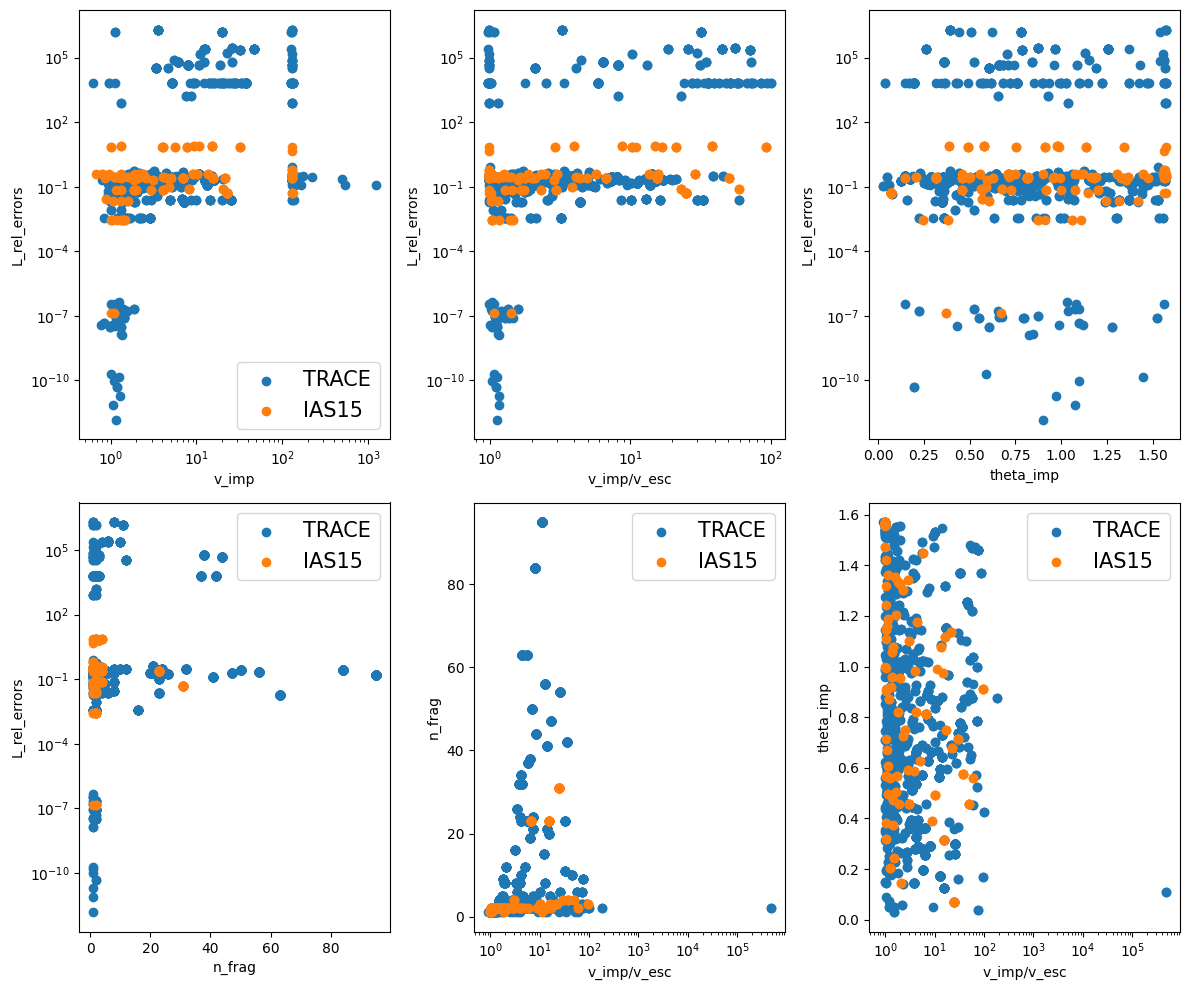

In [231]:
plt.figure(figsize=(12,10))

plt.subplot(2,3,1)
plt.scatter(famtrees_with_arch_trace['v_imp'], famtrees_with_arch_trace['L_rel_errors'], label = 'TRACE')
plt.scatter(famtrees_with_arch_ias15['v_imp'], famtrees_with_arch_ias15['L_rel_errors'], label = 'IAS15')
plt.legend(fontsize=15)
plt.xscale("log")
plt.yscale("log")
plt.xlabel("v_imp")
plt.ylabel("L_rel_errors")

plt.subplot(2,3,2)
plt.scatter(famtrees_with_arch_trace['v_imp/v_esc'], famtrees_with_arch_trace['L_rel_errors'])
plt.scatter(famtrees_with_arch_ias15['v_imp/v_esc'], famtrees_with_arch_ias15['L_rel_errors'])
plt.xscale("log")
plt.yscale("log")
plt.xlabel("v_imp/v_esc")
plt.ylabel("L_rel_errors")

plt.subplot(2,3,3)
plt.scatter(famtrees_with_arch_trace['theta_imp'], famtrees_with_arch_trace['L_rel_errors'])
plt.scatter(famtrees_with_arch_ias15['theta_imp'], famtrees_with_arch_ias15['L_rel_errors'])
#plt.xscale("log")
plt.yscale("log")
plt.xlabel("theta_imp")
plt.ylabel("L_rel_errors")


plt.subplot(2,3,4)
plt.scatter(famtrees_with_arch_trace['n_frag'], famtrees_with_arch_trace['L_rel_errors'], label = 'TRACE')
plt.scatter(famtrees_with_arch_ias15['n_frag'], famtrees_with_arch_ias15['L_rel_errors'], label = 'IAS15')
plt.legend(fontsize=15)
plt.yscale("log")
plt.xlabel("n_frag")
plt.ylabel("L_rel_errors")

plt.subplot(2,3,5)
plt.scatter(famtrees_with_arch_trace['v_imp/v_esc'], famtrees_with_arch_trace['n_frag'], label = 'TRACE')
plt.scatter(famtrees_with_arch_ias15['v_imp/v_esc'], famtrees_with_arch_ias15['n_frag'], label = 'IAS15')
plt.legend(fontsize=15)
plt.xscale("log")
#plt.yscale("log")
plt.xlabel("v_imp/v_esc")
plt.ylabel("n_frag")

plt.subplot(2,3,6)
plt.scatter(famtrees_with_arch_trace['v_imp/v_esc'], famtrees_with_arch_trace['theta_imp'], label = 'TRACE')
plt.scatter(famtrees_with_arch_ias15['v_imp/v_esc'], famtrees_with_arch_ias15['theta_imp'], label = 'IAS15')
plt.legend(fontsize=15)
plt.xscale("log")
#plt.yscale("log")
plt.xlabel("v_imp/v_esc")
plt.ylabel("theta_imp")



plt.tight_layout()

/Users/honeyeah/miniconda3/envs/reboundx-env/lib/python3.14/site-packages/pandas/core/arraylike.py:399: RuntimeWarning: divide by zero encountered in log10
  result = getattr(ufunc, method)(*inputs, **kwargs)


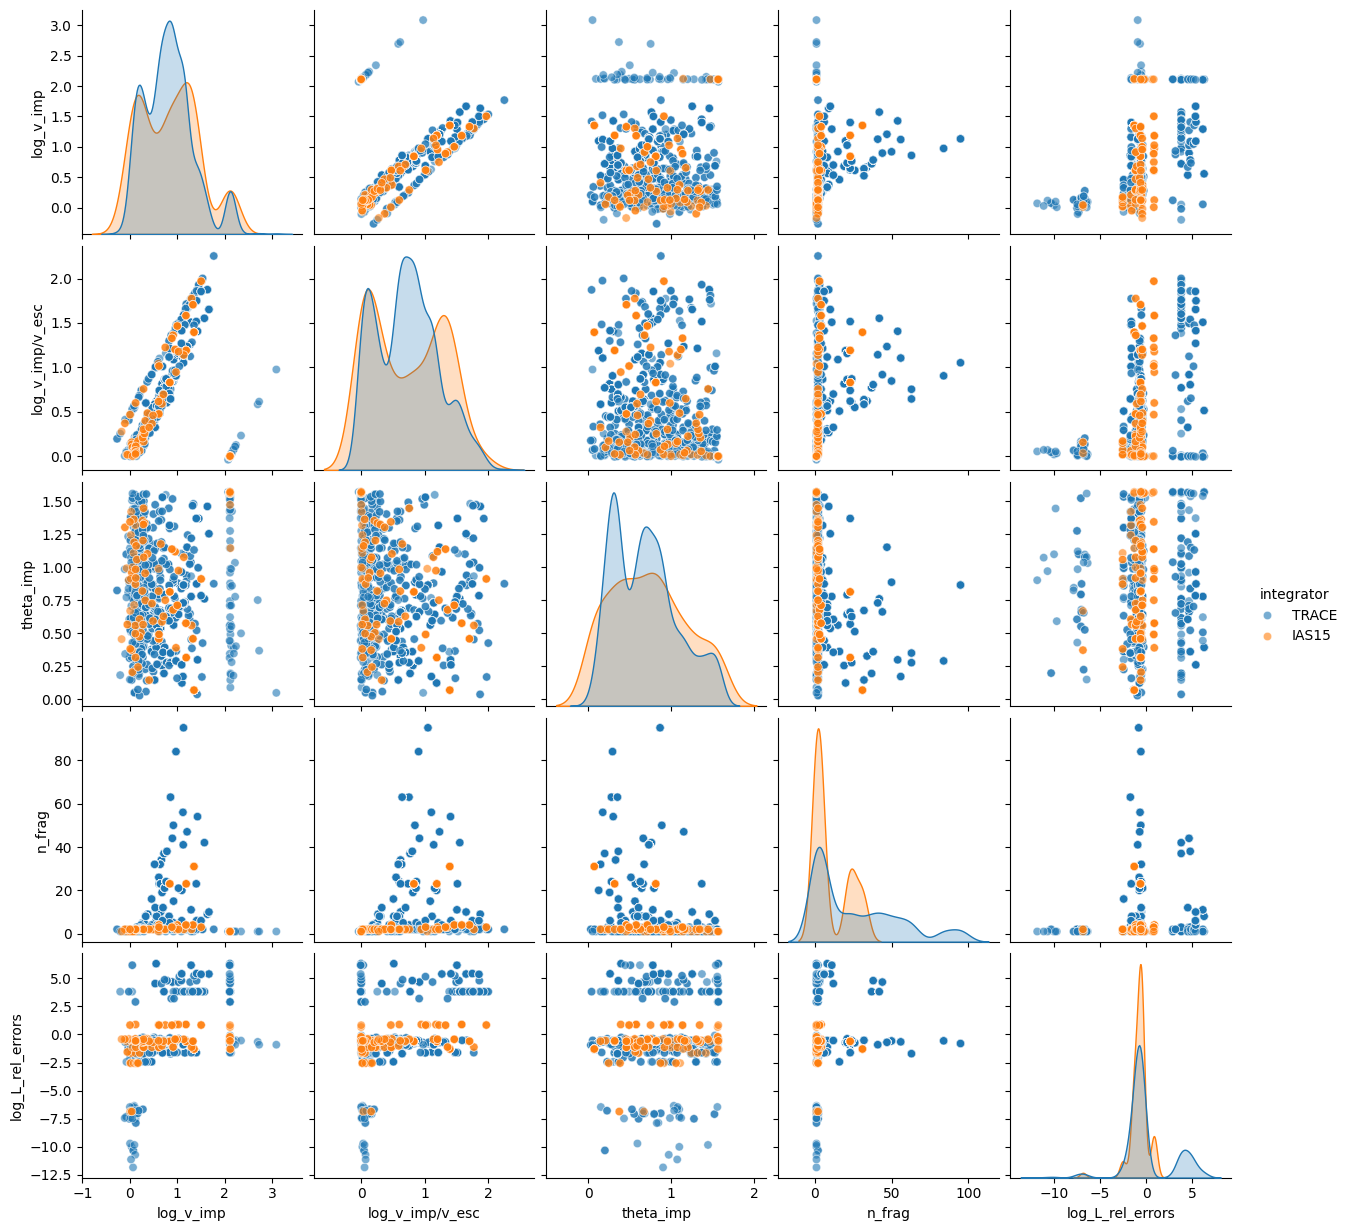

In [237]:
# 1. Add a label column to distinguish the datasets
famtrees_with_arch_trace['integrator'] = 'TRACE'
famtrees_with_arch_ias15['integrator'] = 'IAS15'
famtrees_with_arch_trace_no_outlier = famtrees_with_arch_trace[famtrees_with_arch_trace['v_imp'] < 10**4]

# 2. Combine them into one dataframe
combined_df = pd.concat([famtrees_with_arch_trace_no_outlier, famtrees_with_arch_ias15], ignore_index=True)

# 3. Select the specific columns you want to plot
cols = ['v_imp', 'v_imp/v_esc', 'theta_imp', 'n_frag', 'L_rel_errors', 'integrator']
plot_df = combined_df[cols].copy()

# Note: Seaborn's pairplot doesn't easily allow setting log scales on individual axes. 
# Since your original plots used log scales, it is best to log-transform those columns first.
plot_df['log_L_rel_errors'] = np.log10(plot_df['L_rel_errors'])
plot_df['log_v_imp'] = np.log10(plot_df['v_imp'])
plot_df['log_v_imp/v_esc'] = np.log10(plot_df['v_imp/v_esc'])

# 4. Define the final columns to pass to the plot
final_cols = ['log_v_imp', 'log_v_imp/v_esc', 'theta_imp', 'n_frag', 'log_L_rel_errors', 'integrator']

# 5. Generate the corner plot
sns.pairplot(
    plot_df[final_cols], 
    hue='integrator', 
    diag_kind='kde',        # Shows histograms on the diagonal
    plot_kws={'alpha': 0.6},  # Makes the scatter points slightly transparent
    diag_kws={'common_norm': False} # <-- Add this line
)
